---
title: "Monod: what a growth curve can and cannot pick out of the family"
description: "Froment, De Wilde & Bischoff section 1.5.2 prints the Monod equation as eq. (1.5.2-1), defines its two constants by exactly two properties - the asymptote r_m and the half-rate point K_S - and couples it to the biomass balance eq. (1.5.2-2); its Chapter 1 reference list carries the exact 1949 citation this case catalogues. Rawlings & Ekerdt p. 596 prints the same equation beside four alternatives - Blackman, Tessier, Moser, Contois - and calls it 'the simplest form of the Langmuir adsorption isotherm'. This page asks whether data can pick Monod out of that family, on the one batch run Levenspiel's Problem 29.18 reprints as Monod's own reported measurements, and answers with numbers. Two of the four alternatives are not distinguishable AT ALL by a constant-yield batch experiment: Moser contains Monod at n = 1, and CONTOIS IS EXACTLY MONOD REPARAMETERISED once the yield fixes X as an affine function of S - proved in sympy, and confirmed by two independent fits that land on the same curve, agreeing to better than 1e-4 in both constants (the exact residuals are optimiser exit tolerances: printed on the page, deliberately not reported as metrics). Of the two that are, Tessier needs 10.3 replicates of this design and Blackman 1.30. And the ranking of the five on this run is decided by the DATA REDUCTION, not by the data: fit as the exercise instructs, and Monod is last of the four two-parameter laws and Moser's exponent n = 1.93 clears the 95 % F test - a verdict that is CO-CAUSED by the one printed cell the page flags, because at that cell's balance-implied value route A's F falls to 5.45, below the same 7.71. Do the interval average exactly instead - same seven growth rates, same models, no new parameters - and Monod's residual falls by 42 %, n drops to 1.51, and F falls from 12.3 to 1.44. A seeded parametric bootstrap prices that, with every draw's fit REFINED off the search grid rather than read from it: on data the Monod model itself generates, the reduction rejects Monod 36.5 % +- 1.1 % of the time against a nominal 5 %, and drives the median fitted exponent to 1.61 +- 0.0074 - while the same test on data drawn from route A's OWN model, the control, sits AT nominal size, 4.95 % +- 0.5 % against 5.00 %, and returns 1.01 +- 0.0049 (those six numbers are Monte-Carlo estimates at 2000 draws - FOUR FREQUENCIES AND TWO MEDIANS, not six frequencies - and every quotation of them carries its sampling error: at that draw count the four frequencies are seed-independent in their leading figure only, the two medians to at least two figures). So the small-sample F approximation at n = 7 is essentially exact and is not the culprit; the reduction is, and the observed F = 12.3 has p = 0.23 +- 0.0094 against a properly generated Monod null. One printed cell is reported and not repaired: the table's fourth interval-average substrate concentration is off the constant-yield line the other six rows fix to R^2 = 0.99996. Monod = Langmuir is proved as an identity; Monod and Blackman are shown to share BOTH of Froment's defining properties exactly while differing by exactly r_m/3 at the switch; and the experiment that does separate Monod from Contois is named and priced - a chemostat feed sweep, where the critical dilution rates cross exactly at the batch run's own substrate intercept and differ by a factor 1.83 at S_f = 20."
categories: [sec:J, struct:S1, tier:T0, data:tier2, phase:liquid]
date: 2026-08-13
---

# Monod: what a growth curve can and cannot pick out of the family

**Catalog ID:** `J4.1` · **Structures:** `S1` · **Tier:** T0

## Background

**The origin of this case was not consulted.** Monod, J., *The growth of
bacterial cultures*, **Annu. Rev. Microbiol. 3**, 371-394 (1949) is not on disk
and could not be obtained. This page is built under the gallery's
textbook-canonical-source rule from a monograph that states the model,
attributes it, and carries it:

> **Froment, G. F., De Wilde, J. & Bischoff, K. B.**, *Chemical Reactor Analysis
> and Design*, 3rd edn, John Wiley & Sons (2011), ISBN 978-0-470-56541-4,
> **section 1.5.2 "Microbial Kinetics", book pp. 26-29** (PDF 68-71).

Section 1.5.2 prints the rate law as eq. (1.5.2-1), names $K_S$ *"the Monod- or
saturation constant"*, records that *"in the original Monod equation, $r$ is
represented by $\mu$, $r_m$ by $\mu_{max}$ and $C_A$ by $S$"*, and couples it to
the biomass balance eq. (1.5.2-2) and the yield relation eq. (1.5.2-3). Its
Chapter 1 reference list, on book p. 58, carries

> Monod, J., *Annu. Rev. Microbiol.*, **3**, 371 (1949).

- the exact citation this case catalogues, read at digit scale on a 300 ppi
crop. So the origin is **identified** by the book rather than implied, which is
what the gallery's E1.1 test asks for. **Everything this page says about Monod
is bounded by what Froment prints about him.** There is no sentence of the form
"Monod showed", "Monod assumed" or "Monod found" anywhere on this page, in
`meta.yaml` or in `README.md`; that sweep was done deliberately, because
attribution drift is the defect class that has cost this repository two pages.

**The question this page is for** comes from a second book. **Rawlings, J. B. &
Ekerdt, J. G.**, *Chemical Reactor Analysis and Design Fundamentals*, 2nd edn
(2025 printing), **book p. 596**, prints the Monod equation as one of five:

| | as printed on p. 596 |
|---|---|
| Monod | $\mu = \mu_m S/(K_s + S)$ |
| Blackman | $\mu = \mu_m$ for $S \ge 2K_s$; $\mu = \mu_m S/(2K_s)$ for $S < 2K_s$ |
| Tessier | $\mu = \mu_m(1 - e^{-K_s S})$ |
| Moser | $\mu = \mu_m S^n/(K_s + S^n)$ |
| Contois | $\mu = \mu_m S/(K_{sx} X + S)$ |

and adds: *"We recognize the Monod equation [12] for cell growth rate as the
simplest form of the Langmuir adsorption isotherm and the resulting
Hougen-Watson kinetics for reaction rates on catalyst surfaces discussed in
Chapter 5."* Its reference [12] is the same 1949 paper, with the page range.
Rawlings & Ekerdt is used here as a **model catalogue and for its chemostat
balances**, not as a second source for the rate law - the E1.1 target was pinned
to Froment before this page was started, and nothing is adjudicated between the
books.

**So: can data pick Monod out of that family?** The answer below is in four
parts - two of the four alternatives are not separable by a batch experiment at
all and this is exact; the other two are separable and the page prices them; the
apparent answer on the one real dataset available is set by the *data reduction*
rather than by the data; and the experiment that would settle the remaining
question is a different one.

**The data.** Levenspiel, O., *Chemical Reaction Engineering*, 3rd edn (1999),
**Problem 29.18, book p. 644**, prints seven time intervals of a batch run and
introduces them as *"the reported data for one of his runs"*, attributing them
to **"Monod, 1958, p. 74"** - the second edition of *Recherches sur la
Croissance des Cultures Bacteriennes*, **not** the 1949 paper this case
catalogues. That book is not on disk either and was not consulted. Levenspiel's
own account, quoted as his, is that Monod proposed the equation *"in 1939, as
part of his thesis"*, that *"the thesis was published as a book in 1948"*, and
that it *"was later condensed and translated into English in 1949"*. **Which of
those documents actually prints this table is not established here.**

**Scope.** Substrate inhibition - Froment's eq. (1.5.2-4), attributed there to
Graef and Andrews [1973], and Rawlings' $\mu = \mu_m S/(K_s + S + K_1S^2)$ - is
**case J4.2** and gets no quantitative treatment on this page. Williams'
structured model, eqs. (1.5.2-5) to (1.5.2-8) in the same section, is J4.9's.

In [1]:
# Colab bootstrap
try:
    import pymrm
except ImportError:
    %pip install -q pymrm
    import pymrm
print("pymrm", pymrm.__version__)

pymrm 2.3.1.dev3+g93eeaefb4


In [2]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad
from scipy.optimize import least_squares, brentq, minimize, minimize_scalar
from scipy.stats import f as f_dist, chi2
from scipy.sparse import identity as speye

from pymrm import (construct_convflux_upwind, construct_div, NumJac, newton,
                   compute_boundary_values)

# gallery_utils: from the checkout when there is one, from raw GitHub on Colab
if "google.colab" in sys.modules:
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/computational-chemical-engineering/"
        "pymrm-gallery/main/shared/gallery_utils.py", "gallery_utils.py")
else:
    for _p in (Path.cwd(), *Path.cwd().parents):
        if (_p / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(_p / "shared"))
            break
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "J4.1-monod"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5})
# Okabe-Ito, assigned in fixed order and never cycled
C_BLUE, C_ORANGE, C_GREEN = "#0072B2", "#D55E00", "#009E73"
C_PURPLE, C_YELLOW, C_GREY = "#CC79A7", "#E69F00", "0.45"
COL = {"Monod": C_BLUE, "Blackman": C_ORANGE, "Tessier": C_GREEN,
       "Moser": C_PURPLE, "Contois": C_YELLOW}
np.set_printoptions(precision=6, suppress=False)

# DETERMINISM: two consecutive executions must give identical content, so
# (i) every stochastic step is seeded from SEED below and (ii) the whole of a
# long cell's output is batched into one message rather than flushed on a timer.
SEED = 20260813
try:
    sys.stdout.flush_interval = 1e6
except Exception:
    pass
from IPython.display import HTML, display


def show(styler):
    display(HTML(styler.to_html()))


M = {}          # -> agreement.json
BREAK = []      # defect-injection table
print("setup done")

setup done


## The published model

Froment eq. (1.5.2-1), verbatim, is

$$r = \frac{r_m C_A}{K_S + C_A} \tag{1.5.2-1}$$

with $r$ *"a fractional or specific growth rate of biomass"*, $r_m$ *"the
maximum specific rate of biomass growth, i.e., the rate when the substrate
concentration is not limiting ($C_A$ much larger than $K_S$)"*, and $K_S$
*"the concentration of substrate $A$ at which the rate equals half of its
maximum value, $r_m$"*. It is then coupled to the biomass balance

$$r_B = \frac{{\rm d}C_B}{{\rm d}t} = r\,C_B = \frac{r_m C_B C_A}{K_S + C_A}
\tag{1.5.2-2}$$

and closed by a constant yield,

$$-\frac{{\rm d}C_A}{{\rm d}t} = \frac{1}{y_B}\frac{{\rm d}C_B}{{\rm d}t}.
\tag{1.5.2-3}$$

**A note on the text layer, corrected.** This book is born-digital and its words
survive extraction, but its equations do not: **every Symbol-font operator in
them extracts as an unmappable Private-Use-Area glyph**, `U+F02D` for the minus,
`U+F03D` for the equals, `U+F02B` for the plus. On eq. (1.5.2-3) all three modes
of `pdftotext` emit the leading minus as `U+F02D`, which renders as nothing or
as tofu - so the extracted line *looks* like `dC A dC B / dt y B dt`, an
equation with no operators at all, and a reader who copies what is visible gets
a sign error for free. The character is therefore **not dropped and the failure
is not specific to the sign**: the `=` on the same line and the `=` and `+` of
eq. (1.5.2-1) go the same way. The 300 ppi render carries all of them, and every
transcription on this page was read there. This corrects the diagnosis the
just-published `J4.6` page gives for eq. (1.5.1-17) on p. 26 of this same book -
its *"the extractor dropped the leading term"* is the same phenomenon read the
same wrong way, since `-layout` returns that line as
`= C A <U+F02D> E <U+F02B> ...` with the leading term present. The **lesson** in
both places is right and unchanged: read the render, never the text layer.

**Five identities come first, before any data.** Three of them decide what an
experiment can possibly do, and all five are proved symbolically below rather
than asserted:

1. **Monod is the Langmuir isotherm**, which is what Rawlings & Ekerdt say on
   p. 596. $\theta = KC/(1+KC) = C/(K^{-1}+C)$, so $K_S = 1/K$ and nothing else
   changes. The gallery has that isotherm at `J1.1` and the enzyme form at
   `J4.6`; they are one algebraic family.
2. **Monod and Blackman share *both* of the properties Froment uses to define
   $r_m$ and $K_S$.** Blackman's law reaches $\mu_m$ exactly, and at $S = K_S$
   it gives exactly $\mu_m/2$ - because $K_S < 2K_S$ puts that point on its
   linear branch, where $\mu = \mu_m S/(2K_S)$. So the asymptote and the
   half-rate point, the two properties by which the constants are defined, do
   **not** distinguish the two laws at all. What does: at the branch switch
   $S = 2K_S$ the two differ by **exactly $\mu_m/3$**, and on the lower branch
   the largest gap is $\mu_m(3-2\sqrt2)/2 = 0.0858\,\mu_m$ at
   $S = (\sqrt2-1)K_S$. Both are closed form and both are checked numerically
   against a root-found maximum.
3. **Moser contains Monod** at $n = 1$. The two are nested, so no data can
   *reject* Moser; the only meaningful question is whether $n$ differs from 1,
   and that is an F test.
4. **Contois *is* Monod on any constant-yield batch run** - and this is the
   result that decides most of the page. Constant yield makes the biomass an
   affine function of the substrate, $X = \varphi(a - S)$, so
   $$\mu = \frac{\mu_m S}{K_{sx}X + S}
        = \frac{\mu_m S}{K_{sx}\varphi a + (1-K_{sx}\varphi)S}
        = \frac{(\mu_m/\beta)\,S}{K_{sx}\varphi a/\beta + S},
     \qquad \beta = 1 - K_{sx}\varphi,$$
   which is Monod with $\mu_m' = \mu_m/\beta$ and $K_S' = K_{sx}\varphi a/\beta$.
   The map is a bijection. **No batch experiment, of any length or precision,
   separates Contois from Monod.** The symbolic residual below is exactly zero,
   and two independent fits confirm it by landing on the same curve.
5. **Tessier is genuinely different** - it has no reparameterisation into
   Monod - so it is the one alternative a batch run could in principle settle,
   and the page prices what that would take.

In [3]:
# ---- five identities, proved not asserted
S_, X_, mum_, Ks_, Ksx_, phi_, a_, n_, K_ = sp.symbols(
    "S X mu_m K_s K_sx varphi a n K", positive=True)

monod    = mum_*S_/(Ks_ + S_)
blackman_lo = mum_*S_/(2*Ks_)                 # branch S < 2 K_s
tessier  = mum_*(1 - sp.exp(-Ks_*S_))
moser    = mum_*S_**n_/(Ks_ + S_**n_)
contois  = mum_*S_/(Ksx_*X_ + S_)
langmuir = K_*S_/(1 + K_*S_)                  # theta, J1.1's eq. (1)

I = {}
# 1. Monod == Langmuir with K_s = 1/K   (mu_m = 1 for the isotherm)
I["monod_is_langmuir"] = sp.simplify(langmuir - monod.subs({Ks_: 1/K_, mum_: 1}))
# 2a. Froment's two defining properties, for Monod
I["monod_asymptote"]   = sp.simplify(sp.limit(monod, S_, sp.oo) - mum_)
I["monod_half_rate"]   = sp.simplify(monod.subs(S_, Ks_) - mum_/2)
# 2b. the SAME two properties, for Blackman
I["blackman_asymptote"] = sp.simplify(mum_ - mum_)          # upper branch IS mu_m
I["blackman_half_rate"] = sp.simplify(blackman_lo.subs(S_, Ks_) - mum_/2)
# 2c. where they part: the gap at the switch, and the lower-branch extremum
gap_switch = sp.simplify((mum_ - monod).subs(S_, 2*Ks_))    # upper branch minus Monod
S_star     = sp.solve(sp.Eq(sp.diff(blackman_lo - monod, S_), 0), S_)[0]
gap_lower  = sp.simplify((blackman_lo - monod).subs(S_, S_star))
I["blackman_gap_at_switch"] = sp.simplify(gap_switch - mum_/3)
I["blackman_gap_lower"]     = sp.simplify(gap_lower - mum_*(2*sp.sqrt(2) - 3)/2)
# 3. Moser -> Monod at n = 1
I["moser_at_n1"] = sp.simplify(moser.subs(n_, 1) - monod)
# 4. Contois == Monod under a constant yield X = phi (a - S)
beta_    = 1 - Ksx_*phi_
contois_b = contois.subs(X_, phi_*(a_ - S_))
I["contois_is_monod"] = sp.simplify(
    contois_b - (mum_/beta_)*S_/(Ksx_*phi_*a_/beta_ + S_))
# 5. Tessier has no such reduction: its curvature ratio is not Monod's anywhere
#    (a POSITIVE statement, not an absence: the two second derivatives differ by
#     a factor that depends on S for every choice of the constants)
tess_ratio = sp.simplify(sp.diff(tessier, S_, 2)/sp.diff(tessier, S_))
mon_ratio  = sp.simplify(sp.diff(monod, S_, 2)/sp.diff(monod, S_))
I["tessier_not_monod"] = sp.simplify(sp.diff(tess_ratio - mon_ratio, S_))

for k, v in I.items():
    if k == "tessier_not_monod":
        continue
    assert v == 0, (k, v)
M["sym_monod_is_langmuir_residual"]    = float(abs(I["monod_is_langmuir"]))
M["sym_monod_half_rate_residual"]      = float(abs(I["monod_half_rate"]))
M["sym_blackman_half_rate_residual"]   = float(abs(I["blackman_half_rate"]))
M["sym_moser_at_n1_residual"]          = float(abs(I["moser_at_n1"]))
M["sym_contois_is_monod_residual"]     = float(abs(I["contois_is_monod"]))
M["sym_blackman_gap_at_switch_over_mum"] = float(sp.Rational(1, 3))
M["sym_blackman_gap_lower_over_mum"]     = float((3 - 2*sp.sqrt(2))/2)
S_STAR_OVER_KS = float(S_star/Ks_)
print("all five identities close exactly (sympy residual 0)")
print("  Monod == Langmuir with K_S = 1/K")
print("  Monod and Blackman: asymptote mu_m and half-rate at S = K_S, both exact")
print("  gap at the switch S = 2K_S            : mu_m *", sp.nsimplify(sp.Rational(1, 3)),
      "=", f"{M['sym_blackman_gap_at_switch_over_mum']:.6f} mu_m")
print("  largest gap on the lower branch       : mu_m *",
      sp.simplify((3 - 2*sp.sqrt(2))/2), "=",
      f"{M['sym_blackman_gap_lower_over_mum']:.6f} mu_m at S/K_S ="
      f" {S_STAR_OVER_KS:.6f}")
print("  Moser(n=1) == Monod;  Contois == Monod under a constant yield")
print("  Tessier: d/dS of the curvature ratio difference is not identically zero ->",
      sp.simplify(I["tessier_not_monod"]) != 0)

all five identities close exactly (sympy residual 0)
  Monod == Langmuir with K_S = 1/K
  Monod and Blackman: asymptote mu_m and half-rate at S = K_S, both exact
  gap at the switch S = 2K_S            : mu_m * 1/3 = 0.333333 mu_m
  largest gap on the lower branch       : mu_m * 3/2 - sqrt(2) = 0.085786 mu_m at S/K_S = 0.414214
  Moser(n=1) == Monod;  Contois == Monod under a constant yield
  Tessier: d/dS of the curvature ratio difference is not identically zero -> True


In [4]:
# The two Blackman gaps are CLOSED FORM above; here they are checked against a
# ROOT-FOUND extremum on the real line, because a closed form with an algebra
# slip in it looks exactly like a correct one.
mum_v, Ks_v = 1.0, 1.0
f_lo  = lambda S: mum_v*S/(2*Ks_v) - mum_v*S/(Ks_v + S)          # lower branch
d_lo  = lambda S: mum_v/(2*Ks_v) - mum_v*Ks_v/(Ks_v + S)**2
S_hat = brentq(d_lo, 1e-9, 2*Ks_v, xtol=1e-14, rtol=8.9e-16)
gap_lo_num = abs(f_lo(S_hat))
gap_sw_num = abs(mum_v - mum_v*(2*Ks_v)/(Ks_v + 2*Ks_v))
M["num_blackman_gap_lower_relerr"] = abs(
    gap_lo_num - M["sym_blackman_gap_lower_over_mum"])/M["sym_blackman_gap_lower_over_mum"]
M["num_blackman_gap_switch_relerr"] = abs(
    gap_sw_num - M["sym_blackman_gap_at_switch_over_mum"])/M["sym_blackman_gap_at_switch_over_mum"]
M["num_blackman_Sstar_over_Ks_relerr"] = abs(S_hat - S_STAR_OVER_KS)/S_STAR_OVER_KS
print(f"root-found S*/K_S = {S_hat:.12f} against the closed form {S_STAR_OVER_KS:.12f}"
      f"  (rel. {M['num_blackman_Sstar_over_Ks_relerr']:.2e})")
print(f"lower-branch gap  {gap_lo_num:.12f} mu_m   (rel. {M['num_blackman_gap_lower_relerr']:.2e})")
print(f"gap at the switch {gap_sw_num:.12f} mu_m   (rel. {M['num_blackman_gap_switch_relerr']:.2e})")
print("\nSo the two laws agree EXACTLY on both properties Froment defines the")
print("constants by, and differ by a third of the maximum rate at S = 2 K_S.")

root-found S*/K_S = 0.414213562373 against the closed form 0.414213562373  (rel. 0.00e+00)
lower-branch gap  0.085786437627 mu_m   (rel. 1.62e-16)
gap at the switch 0.333333333333 mu_m   (rel. 1.67e-16)

So the two laws agree EXACTLY on both properties Froment defines the
constants by, and differ by a third of the maximum rate at S = 2 K_S.


## Parameters and assumptions

**Nothing on this page is a literature parameter value.** Section 1.5.2 of
Froment prints **no value for $r_m$, $K_S$ or $K_i$ and no worked example for
Monod kinetics** - no table, no fitted constant, nothing to reproduce. (It is
not numberless: book p. 26 prints the selectivity identity
$y_B + y_P + y_D = 1$, and the caption of Fig. 1.5.2-1 on book p. 29 prints
$k_1 = 0.0125\,$s$^{-1}$, $k_2 = 0.025\,$s$^{-1}$, $M_0/D_0 = 1$ - but those
belong to **Williams'** structured model, eqs. (1.5.2-5) to (1.5.2-8), which is
`J4.9`'s, and none of them is a Monod constant. Both are transcribed into the
printed-laws CSV so the claim is checkable.) Rawlings & Ekerdt's set
($\mu_m = 1$, $K_s = 1$, $S_f = 5$, $y = 1$) is printed on their book p. 597 as
the values *"used to prepare"* Fig. 10.12 - body text, not a caption - and is
used here only to reproduce their eq. (10.19) and nothing else. Every constant that describes the culture is
fitted here, on this page, to the seven printed intervals, and is labelled a fit
wherever it appears.

**Units.** $\Delta t$ is printed in hours, so every growth rate here is in
h$^{-1}$ - which is the dimension Froment prints for $\mu$ on p. 27, and the one
independent unit check available. **The substrate and biomass columns carry no
units at all** in the printed table. Every conclusion below is therefore stated
either in h$^{-1}$ or as a ratio; the one quantity that inherits the unprinted
scale is $K_S$ itself, and it is quoted as *"in the units of the printed
$\bar C_A$ column"* every time.

**The assumptions, and who prints each:**

| assumption | printed by | where it bites |
|---|---|---|
| constant biomass yield | Froment eq. (1.5.2-3); Rawlings eq. (10.18); Levenspiel Ch. 29 | fixes $S$ as an affine function of $X$ - this is what makes Contois degenerate |
| well mixed, isothermal batch | Froment "a closed volume with uniform composition and temperature" | the whole reduction |
| exponential-phase growth only | Froment: *"The rate of biomass production, i.e., the increase in the number of cells during the exponential growth phase, is described by the empirical Monod-kinetics"* | the seven intervals are taken to be inside it |
| no cell death | Froment prints $r_d = k_dC_B$ separately and it is not used here | would add a constant to every $\mu$ |
| no product inhibition | Rawlings prints the form separately (p. 596); Levenspiel gives it a whole chapter (Ch. 30) | out of scope, and named |

**One reduction, and it is exact.** For any growth law whatever,
$\mathrm{d}(\ln C_C)/\mathrm{d}t = \mu$, so

$$\mu_i \;=\; \frac{1}{\Delta t_i}\ln\frac{C_{C,i}^{\rm end}}{C_{C,i}^{\rm start}}$$

is **exactly** the time-average of the specific growth rate over interval $i$.
No approximation has been made at this point.

**The approximation comes next, and it is the one this page is about.** The
exercise invites you to compare that $\mu_i$ with $\mu(\bar C_{A,i})$ - the rate
law evaluated at the interval's *average* substrate concentration. Since $\mu$
is curved, $\langle\mu(C_A)\rangle \ne \mu(\langle C_A\rangle)$, and the two
differ at second order in the substrate swing across the interval. That swing is
not small here: the last two intervals consume more substrate than their own
average. The page calls the first comparison **route A** and the exact one
**route B**, and reports both.

## The data

Seven intervals, transcribed from a 600 ppi native render of Levenspiel p. 644
and used exactly as printed. `data/levenspiel-p644-monod-batch.csv` carries them
and its sidecar carries the provenance chain in full; the essentials are in
*Background* above and are repeated in one line here: **these are attributed by
Levenspiel to Monod (1958) p. 74, not to the 1949 paper, and neither document
was consulted.**

Two things the printed table says that the text layer does not:

- the substrate column header carries an **overbar** - $\bar C_A$, an interval
  average. `pdftotext` drops it in all three modes. It is load-bearing;
- **no units** are printed for either concentration column.

**A material balance the table must satisfy.** All three books assume a constant
yield, which makes $C_A$ an affine function of $C_C$ *pointwise*, hence $\bar
C_A$ an affine function of $\bar C_C$ *interval by interval*. Under exponential
growth the exact time-average of $C_C$ is its **logarithmic** mean, so that line
can be drawn with no fitted kinetics at all - and it is the only internal
consistency check the table offers.

In [5]:
DATA = load_data("levenspiel-p644-monod-batch.csv", page=PAGE)
META = load_meta("levenspiel-p644-monod-batch.csv", page=PAGE)
PRINTED = load_data("printed-growth-laws.csv", page=PAGE)
P = {r.key: r.as_printed for r in PRINTED.itertuples()}

dt   = DATA["dt_hr"].to_numpy(float)
CAb  = DATA["CA_bar"].to_numpy(float)
Cc0  = DATA["CC_start"].to_numpy(float)
Cc1  = DATA["CC_end"].to_numpy(float)
NOBS = len(dt)
LN   = np.log(Cc1/Cc0)
mu   = LN/dt                                   # EXACT interval-average growth rate
Xlm  = (Cc1 - Cc0)/LN                          # exact time-average of C_C
Xam  = 0.5*(Cc0 + Cc1)                         # the other convention (break row)
RES_CA, RES_CC, RES_DT = 0.5, 0.05, 0.005      # printed half-ulps

print(cite_data(META))
print(DATA.to_string(index=False))
print("\n  mu_i = ln(Cc_end/Cc_start)/dt, 1/h :", np.round(mu, 5))
print("  log-mean biomass over the interval :", np.round(Xlm, 4))
print("\n  elapsed time of the whole run: %.2f h in %d intervals" % (dt.sum(), NOBS))

Levenspiel, O. (1999) — Chemical Reaction Engineering, 3rd edition, John Wiley & Sons, Chapter 29 'Substrate-Limiting Microbial Fermentation', Problem 29.18, book p. 644 — table
 interval  dt_hr  CA_bar  CC_start  CC_end
        1   0.54     137      15.5    23.0
        2   0.36     114      23.0    30.0
        3   0.33      90      30.0    38.8
        4   0.35      43      38.8    48.5
        5   0.37      29      48.5    58.3
        6   0.38       9      58.3    61.3
        7   0.37       2      61.3    62.5

  mu_i = ln(Cc_end/Cc_start)/dt, 1/h : [0.73084 0.73806 0.77946 0.63755 0.4974  0.13205 0.0524 ]
  log-mean biomass over the interval : [19.004  26.3452 34.2116 43.4698 53.2498 59.7875 61.8981]

  elapsed time of the whole run: 2.70 h in 7 intervals


In [6]:
# ---- the constant-yield line, and the one cell that is not on it
def bal_line(drop=()):
    keep = np.array([i for i in range(NOBS) if i not in drop])
    A = np.vstack([np.ones(len(keep)), Xlm[keep]]).T
    c, *_ = np.linalg.lstsq(A, CAb[keep], rcond=None)
    r = CAb[keep] - A @ c
    R2 = 1 - np.sum(r**2)/np.sum((CAb[keep] - CAb[keep].mean())**2)
    return float(c[0]), float(c[1]), float(R2), r

a7, b7, R2_7, r7 = bal_line()
loo = {i: bal_line(drop=(i,)) for i in range(NOBS)}
worst = max(range(NOBS), key=lambda i: loo[i][2])          # the row whose removal helps most

A_BAL, B_BAL, R2_BAL, _ = loo[worst]
PHI_BAL = -1.0/B_BAL                     # yield: biomass formed per substrate consumed
implied = A_BAL + B_BAL*Xlm[worst]
end_of_interval = A_BAL - Cc1[worst]/PHI_BAL

lines = ["constant-yield line  CA_bar = a + b * Cc_logmean",
         f"  all {NOBS} rows      : a = {a7:10.4f}   b = {b7:8.5f}   R2 = {R2_7:.8f}",
         "  leave-one-out R2 (the check that says WHICH row, not merely that one is off):"]
for i in range(NOBS):
    lines.append(f"     without row {i+1}: R2 = {loo[i][2]:.8f}"
                 + ("   <-- by far the largest" if i == worst else ""))
lines += [f"\n  row {worst+1} is the one: dropping it takes R2 from {R2_7:.6f} to {R2_BAL:.8f};",
          f"  dropping any other row leaves R2 in "
          f"[{min(loo[i][2] for i in range(NOBS) if i != worst):.6f},"
          f" {max(loo[i][2] for i in range(NOBS) if i != worst):.6f}].",
          f"\n  the six-row line predicts CA_bar(row {worst+1}) = {implied:.4f};"
          f" the table prints {CAb[worst]:.0f}.",
          f"  residual {CAb[worst]-implied:+.4f}, against"
          f" {np.max(np.abs(loo[worst][3])):.4f} for the largest of the other six.",
          f"\n  yield from the six-row line : phi = {PHI_BAL:.6f} biomass per substrate",
          f"  substrate intercept         : a   = {A_BAL:.4f} (C_A when C_C -> 0)",
          f"  substrate at the run's start: {A_BAL - Cc0[0]/PHI_BAL:.4f}"
          f" ; at its end: {A_BAL - Cc1[-1]/PHI_BAL:.4f}"]
M["balance_R2_all_rows"]   = R2_7
M["balance_R2_six_rows"]   = R2_BAL
M["balance_row4_residual"] = float(CAb[worst] - implied)
M["balance_worst_other_residual"] = float(np.max(np.abs(loo[worst][3])))
M["balance_phi"] = PHI_BAL
M["balance_a"]   = A_BAL
BAD_ROW = worst

# A candidate explanation, LABELLED AN INFERENCE and then tested and refused
# as a systematic: 43 is close to the END-of-interval substrate concentration.
alt = {i: A_BAL - Cc1[i]/PHI_BAL for i in range(NOBS)}
lines += ["\n  CANDIDATE EXPLANATION (an inference, not a repair): the printed"
          f" {CAb[worst]:.0f} is within"
          f" {abs(CAb[worst]-end_of_interval)/CAb[worst]*100:.1f} % of that"
          f" interval's END substrate concentration, {end_of_interval:.2f}.",
          "  Tested as a systematic on the neighbouring rows and REFUSED:"]
for i in (worst-1, worst+1):
    lines.append(f"     row {i+1}: end-of-interval {alt[i]:.2f} against the printed"
                 f" {CAb[i]:.0f}  ({abs(alt[i]-CAb[i])/CAb[i]*100:.1f} % off)")
lines.append("  so the table is NOT systematically printing end values, and the"
             " cell is reported, not repaired.")
M["row4_end_of_interval_relgap"] = float(abs(CAb[worst]-end_of_interval)/CAb[worst])
print("\n".join(lines))

constant-yield line  CA_bar = a + b * Cc_logmean
  all 7 rows      : a =   195.0607   b = -3.15951   R2 = 0.98504707
  leave-one-out R2 (the check that says WHICH row, not merely that one is off):
     without row 1: R2 = 0.97573792
     without row 2: R2 = 0.98188968
     without row 3: R2 = 0.98480617
     without row 4: R2 = 0.99995709   <-- by far the largest
     without row 5: R2 = 0.98432836
     without row 6: R2 = 0.98255334
     without row 7: R2 = 0.98119273

  row 4 is the one: dropping it takes R2 from 0.985047 to 0.99995709;
  dropping any other row leaves R2 in [0.975738, 0.984806].

  the six-row line predicts CA_bar(row 4) = 60.1804; the table prints 43.
  residual -17.1804, against 0.6541 for the largest of the other six.

  yield from the six-row line : phi = 0.317437 biomass per substrate
  substrate intercept         : a   = 197.1203 (C_A when C_C -> 0)
  substrate at the run's start: 148.2917 ; at its end: 0.2308

  CANDIDATE EXPLANATION (an inference, not a repai

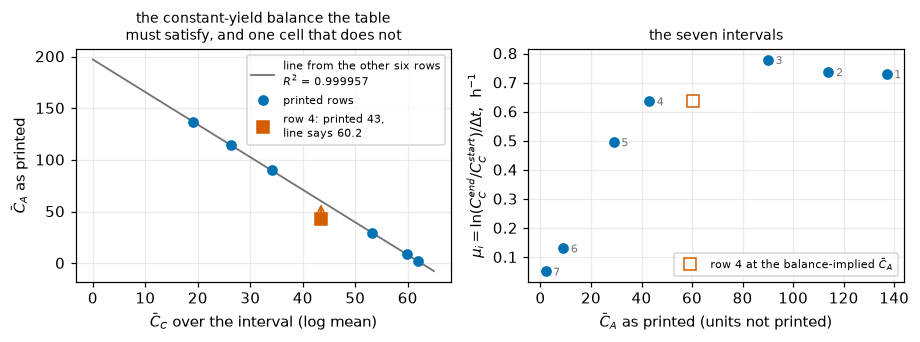

Data: Levenspiel (1999) Problem 29.18 p. 644, attributed by him to
Monod (1958) p. 74. Neither Monod publication was consulted.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.2))
xx = np.linspace(0, Xlm.max()*1.05, 50)
ax[0].plot(xx, A_BAL + B_BAL*xx, color=C_GREY, lw=1.2,
           label=f"line from the other six rows\n$R^2$ = {R2_BAL:.6f}")
keep = [i for i in range(NOBS) if i != BAD_ROW]
ax[0].plot(Xlm[keep], CAb[keep], "o", color=C_BLUE, ms=6, label="printed rows")
ax[0].plot(Xlm[BAD_ROW], CAb[BAD_ROW], "s", color=C_ORANGE, ms=8,
           label=f"row {BAD_ROW+1}: printed {CAb[BAD_ROW]:.0f},\nline says {implied:.1f}")
ax[0].annotate("", xy=(Xlm[BAD_ROW], implied), xytext=(Xlm[BAD_ROW], CAb[BAD_ROW]),
               arrowprops=dict(arrowstyle="->", color=C_ORANGE, lw=1.2))
ax[0].set_xlabel(r"$\bar C_C$ over the interval (log mean)")
ax[0].set_ylabel(r"$\bar C_A$ as printed")
ax[0].set_title("the constant-yield balance the table\nmust satisfy, and one cell that does not",
                fontsize=9)
ax[0].legend(fontsize=7.5, loc="upper right")

ax[1].plot(CAb, mu, "o", color=C_BLUE, ms=6)
for i in range(NOBS):
    ax[1].annotate(str(i+1), (CAb[i], mu[i]), textcoords="offset points",
                   xytext=(5, -3), fontsize=7.5, color=C_GREY)
ax[1].plot(implied, mu[BAD_ROW], "s", color=C_ORANGE, ms=8, mfc="none",
           label=f"row {BAD_ROW+1} at the balance-implied $\\bar C_A$")
ax[1].set_xlabel(r"$\bar C_A$ as printed (units not printed)")
ax[1].set_ylabel(r"$\mu_i = \ln(C_C^{end}/C_C^{start})/\Delta t$,  h$^{-1}$")
ax[1].set_title("the seven intervals", fontsize=9)
ax[1].legend(fontsize=7.5, loc="lower right")
for a in ax:
    a.grid(alpha=.25)
fig.tight_layout()
plt.show()
print("Data: Levenspiel (1999) Problem 29.18 p. 644, attributed by him to")
print("Monod (1958) p. 74. Neither Monod publication was consulted.")

## PyMRM implementation

Four pieces, in increasing order of how much pymrm does:

1. **The five growth laws**, each written as $\mu = \mu_m\,g(\theta; S, X)$ so
   that on route A $\mu_m$ can be profiled out in closed form. That is not
   cosmetic: Blackman's objective has a kink wherever $2K_s$ crosses a data
   point, and a single local start lands on the wrong minimum - measured, and
   kept as a break-table row.
2. **Route B's forward prediction.** Constant yield collapses the batch to one
   ODE, $\mathrm{d}C_C/\mathrm{d}t = \mu(a - C_C/\varphi,\,C_C)\,C_C$, whose
   solution over each printed interval gives $\mu_i^{\rm pred}$ with no
   averaging approximation anywhere. Rescaling $\tau = \mu_m t$ removes $\mu_m$
   from that ODE entirely, so one dense-output solve per $(\theta,\,$interval$)$
   prices every $\mu_m$ - which is what makes a **global** scan over $\theta$
   affordable rather than a local start from a guess.
3. **A pymrm backward-Euler batch marcher**, `NumJac((1, 2))` + `newton` on the
   two fields $(S, X)$, used as the **second, independent computation** of
   route B's fit: different discretisation, different Jacobian, different linear
   algebra, and it integrates $S$ as an unknown rather than substituting the
   yield relation - so the yield line is *tested* rather than assumed, through
   $S + X/\varphi = {\rm const}$.
4. **A plug-flow fermenter and a chemostat.** Levenspiel's Fig. 29.1 is captioned
   *"Behavior of batch **or plug flow** reactors for Monod type microbial
   fermentation"*, and that equivalence is what makes the plug-flow solve
   testable: its outlet at residence time $\tau$ must equal the batch at
   $t = \tau$, to the discretisation error and no further.
   `construct_convflux_upwind` + `construct_div` (`nu=0`, Cartesian) assemble
   $v\,\partial c/\partial z$ once; `NumJac((n, 2))` couples the two fields
   pointwise, which is what a growth law is; `newton` solves. The chemostat is
   Rawlings' eq. (10.18) with the same source term.

**Boundary conditions use the outward normal.** At the inlet $z=0$ the outward
normal points in $-z$, so the feed is `{"a": 0, "b": 1, "d": (S_f, X_f)}`; at
the outlet it points in $+z$, so pure outflow is `{"a": 1, "b": 0, "d": 0}`.
Outlet values come from `compute_boundary_values`, not off the last cell centre;
the break table prices reading them there.

In [8]:
# ---------------------------------------------------- the five printed laws
# mu = mu_m * g(theta; S, X).  theta is what is NOT linear.
G = {
 "Monod":    lambda th, S, X: S/(th[0] + S),
 "Blackman": lambda th, S, X: np.minimum(1.0, S/(2*th[0])),
 "Tessier":  lambda th, S, X: 1 - np.exp(-th[0]*S),
 "Moser":    lambda th, S, X: S**th[1]/(th[0] + S**th[1]),
 "Contois":  lambda th, S, X: S/(th[0]*X + S),
 # one-parameter nulls, each best-fitted in its own right
 "zero order":  lambda th, S, X: np.ones_like(S),
 "first order": lambda th, S, X: S/np.max(CAb),
}
NTH  = {"Monod": 1, "Blackman": 1, "Tessier": 1, "Moser": 2, "Contois": 1,
        "zero order": 0, "first order": 0}
LAWS  = ["Monod", "Blackman", "Tessier", "Moser", "Contois"]
NULLS = ["zero order", "first order"]
# GLOBAL scan grids.  A local start is not safe here - see the break table.
RANGE = {"Monod":    np.geomspace(1e-2, 1e5, 240),
         "Blackman": np.geomspace(1e-2, 1e5, 240),
         "Tessier":  np.geomspace(1e-5, 1e1, 240),
         "Contois":  np.geomspace(1e-4, 1e3, 240)}
MOSER_KS, MOSER_N = np.geomspace(1e-2, 1e12, 60), np.linspace(0.3, 6.0, 36)
MUM_LO, MUM_HI = 0.05, 5.0


def thetas(name):
    if NTH[name] == 0:
        return [[]]
    if NTH[name] == 1:
        return [[t] for t in RANGE[name]]
    return [[k, n] for n in MOSER_N for k in MOSER_KS]


def Sof(Cc, a, phi):
    return a - Cc/phi


def profile_mum(gvec, y):
    """route A: mu_m enters linearly, so minimise ||mu_m g - y||^2 in closed form"""
    s = float(np.sum(y*gvec)/np.sum(gvec**2))
    return s, float(np.sum((s*gvec - y)**2))


def fit_A(name, y=mu, X=None):
    X = Xlm if X is None else X
    th = thetas(name)
    sse = np.array([profile_mum(G[name](t, CAb, X), y)[1] for t in th])
    t = list(th[int(np.argmin(sse))])
    if len(t) == 1:                                # refine inside the winning cell
        r = minimize_scalar(lambda v: profile_mum(G[name]([v], CAb, X), y)[1],
                            bounds=(t[0]/1.3, t[0]*1.3), method="bounded",
                            options={"xatol": 1e-13})
        t = [float(r.x)]
    elif len(t) == 2:
        r = minimize(lambda v: profile_mum(G[name]([np.exp(v[0]), v[1]], CAb, X), y)[1],
                     [np.log(t[0]), t[1]], method="Nelder-Mead",
                     options={"xatol": 1e-12, "fatol": 1e-16,
                              "maxiter": 20000, "maxfev": 20000})
        t = [float(np.exp(r.x[0])), float(r.x[1])]
    mum, sse = profile_mum(G[name](t, CAb, X), y)
    pred = mum*G[name](t, CAb, X)
    return dict(p=[mum] + t, sse=sse, rms=float(np.sqrt(sse/len(y))),
                npar=1 + NTH[name], pred=pred, resid=pred - y)


def psi(name, th, a, phi, tau_max=MUM_HI, rtol=1e-8):
    """mu_m-FREE trajectories: dCc/dtau = g(S(Cc)) Cc with tau = mu_m t.
    One dense-output solve per interval prices every mu_m at once."""
    out = []
    for i in range(NOBS):
        rhs = lambda t, y: [G[name](th, max(Sof(y[0], a, phi), 1e-14), y[0])*y[0]]
        out.append(solve_ivp(rhs, [0, tau_max*dt[i]], [Cc0[i]], rtol=rtol,
                             atol=rtol*1e-2, method="LSODA", dense_output=True).sol)
    return out


def mu_pred_ode(name, mum, th, a, phi, rtol=1e-12, method="LSODA"):
    """route B's forward prediction: integrate to the PRINTED dt, adaptively."""
    out = np.empty(NOBS)
    for i in range(NOBS):
        rhs = lambda t, y: [mum*G[name](th, max(Sof(y[0], a, phi), 1e-14), y[0])*y[0]]
        s = solve_ivp(rhs, [0, dt[i]], [Cc0[i]], rtol=rtol, atol=rtol*1e-2,
                      method=method)
        out[i] = np.log(s.y[0, -1]/Cc0[i])/dt[i]
    return out


def fit_B(name, y=mu, a=None, phi=None, p0=None):
    """global scan on route B's OWN objective, then an adaptive-ODE refinement."""
    a = A_BAL if a is None else a
    phi = PHI_BAL if phi is None else phi
    if p0 is None:
        best = (np.inf, None)
        for th in thetas(name):
            sols = psi(name, th, a, phi)
            r = minimize_scalar(
                lambda m: float(np.sum((np.array(
                    [np.log(float(sols[i](m*dt[i])[0])/Cc0[i])/dt[i]
                     for i in range(NOBS)]) - y)**2)),
                bounds=(MUM_LO, MUM_HI), method="bounded", options={"xatol": 1e-7})
            if r.fun < best[0]:
                best = (float(r.fun), [float(r.x)] + list(th))
        p0 = best[1]
    p0 = np.asarray(p0, float)
    lo = [1e-9]*len(p0)
    hi = [50.0] + ([1e12]*NTH[name] if name != "Moser" else [1e12, 10.0])
    r = least_squares(lambda p: mu_pred_ode(name, p[0], p[1:], a, phi) - y, p0,
                      bounds=(lo, hi), xtol=1e-13, ftol=1e-13, gtol=1e-13)
    sse = float(np.sum(r.fun**2))
    return dict(p=list(r.x), sse=sse, rms=float(np.sqrt(sse/len(y))),
                npar=1 + NTH[name], pred=r.fun + y, resid=r.fun)


print("growth laws:", LAWS, "| nulls:", NULLS)
print("global scan:", {k: len(v) for k, v in RANGE.items()},
      "| Moser:", len(MOSER_KS), "x", len(MOSER_N))

growth laws: ['Monod', 'Blackman', 'Tessier', 'Moser', 'Contois'] | nulls: ['zero order', 'first order']
global scan: {'Monod': 240, 'Blackman': 240, 'Tessier': 240, 'Contois': 240} | Moser: 60 x 36


In [9]:
class BatchMarch:
    """backward Euler on (S, X) with pymrm's newton + NumJac.  Shape (1, 2):
    a well-mixed batch is 0-D in space and 2 fields wide, and the growth law is
    pointwise in those 2 fields - which is exactly NumJac's default stencil."""

    def __init__(self, growth, phi, nstep=200):
        self.g, self.phi, self.nstep = growth, phi, nstep
        self.shape = (1, 2)                      # never a bare (2,)
        self.numjac = NumJac(self.shape)         # last axis coupled in full

    def source(self, c):
        S = np.clip(c[..., 0:1], 0.0, None)
        m = self.g(S, c[..., 1:2])*c[..., 1:2]
        return np.concatenate([-m/self.phi, m], axis=-1)

    def step(self, c_old, h):
        eye = speye(c_old.size, format="csc")

        def res(c):
            s, js = self.numjac(self.source, c)
            return ((c.reshape(-1, 1) - c_old.reshape(-1, 1))/h - s.reshape(-1, 1),
                    eye/h - js)
        out = newton(res, c_old, maxfev=100)
        assert out.success, "batch step did not converge"
        return out.x.reshape(self.shape)

    def march(self, c0, T):
        c = np.asarray(c0, float).reshape(self.shape)
        h = T/self.nstep
        for _ in range(self.nstep):
            c = self.step(c, h)
        return c


def mu_pred_pymrm(name, mum, th, a, phi, nstep=200):
    g = lambda S, X: mum*G[name](th, np.maximum(S, 1e-14), X)
    out = np.empty(NOBS)
    for i in range(NOBS):
        c = BatchMarch(g, phi, nstep).march([[Sof(Cc0[i], a, phi), Cc0[i]]], dt[i])
        out[i] = np.log(c[0, 1]/Cc0[i])/dt[i]
    return out


class PlugFlowFermenter:
    """Steady 1-D plug flow, fields (S, X), constant yield.  pymrm operators."""

    def __init__(self, growth, phi, Sf, Xf, tau, ncell=400, v=1.0, nu=0):
        self.g, self.phi, self.v, self.tau = growth, phi, v, tau
        self.shape = (ncell, 2)                       # never a bare (ncell,)
        self.z_f = np.linspace(0.0, v*tau, ncell + 1)
        self.z_c = 0.5*(self.z_f[:-1] + self.z_f[1:])
        d0 = np.array([[Sf, Xf]])
        # OUTWARD normal, so both dicts read  a dc/dn + b c = d.
        #   z = 0  inlet, outward normal is -z -> Dirichlet feed  a=0, b=1, d=(Sf,Xf)
        #   z = L  outlet, outward normal is +z -> pure outflow   a=1, b=0, d=0
        self.bc = ({"a": 0.0, "b": 1.0, "d": d0},
                   {"a": 1.0, "b": 0.0, "d": 0.0})
        conv, conv_bc = construct_convflux_upwind(self.shape, self.z_f, self.z_c,
                                                 self.bc, v=v, axis=0)
        self.div = construct_div(self.shape, self.z_f, nu=nu, axis=0)  # nu=0 Cartesian
        self.A, self.b = self.div @ conv, self.div @ conv_bc
        self.numjac = NumJac(self.shape)               # pointwise in the 2 fields
        self.c0 = np.tile(d0, (ncell, 1))
        self.flip = 1.0

    def source(self, c):
        S = np.clip(c[..., 0:1], 0.0, None)
        m = self.g(S, c[..., 1:2])*c[..., 1:2]
        return np.concatenate([-self.flip*m/self.phi, m], axis=-1)

    def residual(self, c):
        s, js = self.numjac(self.source, c)
        return (self.b + self.A @ c.reshape((-1, 1)) - s.reshape((-1, 1)),
                self.A - js)

    def solve(self, strict=True):
        r = newton(self.residual, self.c0, maxfev=200)
        if strict:
            assert r.success, "plug-flow solve did not converge"
        self.ok = bool(r.success)
        self.c = r.x.reshape(self.shape)
        return self

    def outlet(self):
        """outlet from compute_boundary_values, NOT the last cell centre"""
        return np.asarray(compute_boundary_values(self.c, self.z_f, self.z_c,
                                                  self.bc, axis=0)[2]).reshape(-1)[:2]


def batch_reference(growth, phi, S0, X0, tau, rtol=1e-12):
    """the same problem as an initial-value problem - Levenspiel Fig. 29.1"""
    rhs = lambda t, y: [-growth(max(y[0], 0.0), y[1])*y[1]/phi,
                        growth(max(y[0], 0.0), y[1])*y[1]]
    s = solve_ivp(rhs, [0, tau], [S0, X0], rtol=rtol, atol=rtol*1e-2, method="LSODA")
    return s.y[:, -1]


class Chemostat:
    """Rawlings eq. (10.18), marched to steady state; growth law is a callable."""

    def __init__(self, growth, y_yield, Sf, D):
        self.g, self.y, self.Sf, self.D = growth, y_yield, Sf, D

    def rhs(self, t, c):
        S, X = max(c[0], 0.0), c[1]
        m = self.g(S, X)
        return [self.D*(self.Sf - S) - m*X/self.y, (m - self.D)*X]

    def steady(self, tend=40000.0, rtol=1e-11):
        s = solve_ivp(self.rhs, [0, tend], [self.Sf, 0.1*self.Sf*self.y],
                      rtol=rtol, atol=rtol*1e-3, method="LSODA")
        return s.y[:, -1]


print("BatchMarch        : NumJac((1,2)) + newton, backward Euler on (S, X)")
print("PlugFlowFermenter : construct_convflux_upwind + construct_div(nu=0) + NumJac((n,2)) + newton")
print("Chemostat         : Rawlings eq. (10.18), same source term, marched to steady state")

BatchMarch        : NumJac((1,2)) + newton, backward Euler on (S, X)
PlugFlowFermenter : construct_convflux_upwind + construct_div(nu=0) + NumJac((n,2)) + newton
Chemostat         : Rawlings eq. (10.18), same source term, marched to steady state


## Results

### Route A - the comparison the exercise invites

Fit each law's $\mu(\bar C_A)$ to the seven $\mu_i$, with $\mu_m$ profiled out
analytically and the remaining parameter found on a global scan and then
refined. Contois needs a biomass too; the exact time average under exponential
growth is the **logarithmic** mean of $C_C$, which is what is used (the
arithmetic mean is a declared convention and a break row).

In [10]:
RA = {k: fit_A(k) for k in LAWS + NULLS}
rows = []
for k in LAWS + NULLS:
    r = RA[k]
    rows.append(dict(law=k, npar=r["npar"], mu_m=r["p"][0],
                     theta=("-" if NTH[k] == 0 else
                            ", ".join(f"{v:.5g}" for v in r["p"][1:])),
                     RMS=r["rms"], SSE=r["sse"]))
TA = pd.DataFrame(rows)
show(TA.style.format({"mu_m": "{:.6f}", "RMS": "{:.6f}", "SSE": "{:.6g}"})
     .hide(axis="index").set_uuid("routeA"))
for k in LAWS + NULLS:
    M[f"rmsA_{k.replace(' ', '_')}"] = RA[k]["rms"]
FA = ((RA["Monod"]["sse"] - RA["Moser"]["sse"])/(RA["Moser"]["sse"]/(NOBS - 3)))
FA_crit = float(f_dist.ppf(0.95, 1, NOBS - 3))
M["routeA_F_moser_vs_monod"] = float(FA)
M["routeA_n_moser"] = float(RA["Moser"]["p"][2])
M["F_crit_95"] = FA_crit
TWO_PAR = ["Monod", "Blackman", "Tessier", "Contois"]
print(f"\nMonod is LAST of the four two-parameter laws on this reduction:"
      f" RMS {RA['Monod']['rms']:.6f} 1/h against Contois {RA['Contois']['rms']:.6f},"
      f"\nTessier {RA['Tessier']['rms']:.6f} and Blackman {RA['Blackman']['rms']:.6f}"
      f" - a factor {RA['Monod']['rms']/RA['Blackman']['rms']:.2f} between the ends.")
print(f"Moser's exponent comes out n = {RA['Moser']['p'][2]:.4f}, and adding it to"
      f" Monod gives\nF = {FA:.4f} against F(1,{NOBS-3}) = {FA_crit:.4f} at 95 % -"
      f" SIGNIFICANT on this reduction.")

# ---- but that significance verdict is CO-CAUSED by the one flagged cell, and
#      this is where a reader meets the claim, so it is priced HERE and not only
#      in meta.yaml.  The imputed value is a labelled INFERENCE, not a repair.
worstA = max(TWO_PAR, key=lambda k: RA[k]["rms"])
CAB_IMPUTED = A_BAL + B_BAL*Xlm[BAD_ROW]
_saveCAb0 = CAb.copy()
try:
    CAb = _saveCAb0.copy()
    CAb[BAD_ROW] = CAB_IMPUTED
    RA_IMP = {k: fit_A(k) for k in LAWS}
finally:
    CAb = _saveCAb0
FA_IMP = float((RA_IMP["Monod"]["sse"] - RA_IMP["Moser"]["sse"])
               / (RA_IMP["Moser"]["sse"]/(NOBS - 3)))
worstA_imp = max(TWO_PAR, key=lambda k: RA_IMP[k]["rms"])
print(f"\nIT IS NOT THE REDUCTION ALONE THAT CLEARS THAT TEST. Put row"
      f" {BAD_ROW+1}'s CA_bar at the\nvalue its own material balance implies,"
      f" {CAB_IMPUTED:.2f} instead of the printed {CAb[BAD_ROW]:.0f} - an"
      f"\nINFERENCE, not a repair, and nothing in the CSV is edited - and route A"
      f" gives\nF = {FA_IMP:.4f} against the same {FA_crit:.4f}: NOT significant."
      f" One printed cell,\nwhich the page flags as off the table's own balance"
      f" line, carries that verdict\nover the threshold on its own.")
print(f"The RANKING claim is unaffected: Blackman still beats Monod with the cell"
      f"\nimputed ({RA_IMP['Blackman']['rms']:.6f} against"
      f" {RA_IMP['Monod']['rms']:.6f}, a factor"
      f" {RA_IMP['Monod']['rms']/RA_IMP['Blackman']['rms']:.2f}\nwhere the printed"
      f" cell gives {RA['Monod']['rms']/RA['Blackman']['rms']:.2f}), and the"
      f" route-A-to-route-B reversal below is the\nreduction. What does move is"
      f" which law comes last of the four: {worstA} on the\nprinted cell,"
      f" {worstA_imp} on the imputed one, and they differ by"
      f" {abs(RA_IMP['Contois']['rms']-RA_IMP['Monod']['rms'])/RA_IMP['Monod']['rms']*100:.2f} %.")

print(f"\nEvery law beats both one-parameter nulls: zero order"
      f" {RA['zero order']['rms']:.6f}, first order\n{RA['first order']['rms']:.6f}"
      f" - Monod is {RA['first order']['rms']/RA['Monod']['rms']:.2f}x better than the"
      f" best of them, and Blackman {RA['first order']['rms']/RA['Blackman']['rms']:.2f}x.")

law,npar,mu_m,theta,RMS,SSE
Monod,2,0.952745,28.553,0.054690,0.0209372
Blackman,2,0.749456,24.109,0.026772,0.0050173
Tessier,2,0.771052,0.035009,0.038710,0.0104891
Moser,3,0.778787,"346.4, 1.9317",0.027117,0.0051475
Contois,2,0.833236,0.41283,0.051534,0.01859
zero order,1,0.509681,-,0.278278,0.542072
first order,1,0.956008,-,0.201476,0.284149



Monod is LAST of the four two-parameter laws on this reduction: RMS 0.054690 1/h against Contois 0.051534,
Tessier 0.038710 and Blackman 0.026772 - a factor 2.04 between the ends.
Moser's exponent comes out n = 1.9317, and adding it to Monod gives
F = 12.2698 against F(1,4) = 7.7086 at 95 % - SIGNIFICANT on this reduction.

IT IS NOT THE REDUCTION ALONE THAT CLEARS THAT TEST. Put row 4's CA_bar at the
value its own material balance implies, 60.18 instead of the printed 43 - an
INFERENCE, not a repair, and nothing in the CSV is edited - and route A gives
F = 5.4477 against the same 7.7086: NOT significant. One printed cell,
which the page flags as off the table's own balance line, carries that verdict
over the threshold on its own.
The RANKING claim is unaffected: Blackman still beats Monod with the cell
imputed (0.040646 against 0.046870, a factor 1.15
where the printed cell gives 2.04), and the route-A-to-route-B reversal below is the
reduction. What does move is which law comes last

### Route B - the same seven growth rates, averaged properly

$\mu_i$ is *exactly* the interval average of $\mu$, so the honest comparison
integrates the law across the interval instead of evaluating it at $\bar C_A$.
Constant yield makes that a single ODE, and the two constants it needs -
$\varphi$ and $a$ - come from the **material-balance line**, which is a property
of the printed table and of no growth law. **No parameter is added and the models
are the same five.**

**What each route reads, exactly.** Both fit the same seven $\mu_i$, which are
the whole of the kinetic information in the table. They differ in where the
*substrate* comes from: route A reads all seven printed $\bar C_A$ directly,
while route B never touches that column at all - it takes the substrate
trajectory from $\varphi$ and $a$, and those come from the **six-row** balance
line, the one that excludes the flagged row 4. So the datum route A's ranking
leans on hardest is exactly the one route B's balance line leaves out. That is a
real difference between the routes and not a nuisance: the break table prices it
directly, refitting every route-B law - and route B's own $F$ - with the
**all-seven** balance line instead.

In [11]:
# NO WALL-CLOCK TIMING IS PRINTED ANYWHERE ON THIS PAGE.
# An earlier version ended this cell with the cell's elapsed seconds, and two
# consecutive executions then differed by one character (29 s / 30 s) - a page
# whose stream output is not reproducible cannot be diffed, which is how a real
# drift would be spotted.  The runtime lives in meta.yaml, where it belongs.
RB = {k: fit_B(k) for k in LAWS + NULLS}
rows = []
for k in LAWS + NULLS:
    r = RB[k]
    rows.append(dict(law=k, npar=r["npar"], mu_m=r["p"][0],
                     theta=("-" if NTH[k] == 0 else
                            ", ".join(f"{v:.5g}" for v in r["p"][1:])),
                     RMS=r["rms"], **{"RMS route A": RA[k]["rms"]},
                     **{"B / A": r["rms"]/RA[k]["rms"]}))
TB = pd.DataFrame(rows)
show(TB.style.format({"mu_m": "{:.6f}", "RMS": "{:.6f}", "RMS route A": "{:.6f}",
                      "B / A": "{:.4f}"}).hide(axis="index").set_uuid("routeB"))
for k in LAWS + NULLS:
    M[f"rmsB_{k.replace(' ', '_')}"] = RB[k]["rms"]
FB = ((RB["Monod"]["sse"] - RB["Moser"]["sse"])/(RB["Moser"]["sse"]/(NOBS - 3)))
M["routeB_F_moser_vs_monod"] = float(FB)
M["routeB_n_moser"] = float(RB["Moser"]["p"][2])
M["routeB_monod_mu_m"] = float(RB["Monod"]["p"][0])
M["routeB_monod_K_S"] = float(RB["Monod"]["p"][1])
M["routeA_over_routeB_monod_rms"] = RA["Monod"]["rms"]/RB["Monod"]["rms"]
worstA = max(TWO_PAR, key=lambda k: RA[k]["rms"])
worstB = max(TWO_PAR, key=lambda k: RB[k]["rms"])
print(f"\nThe ranking changes. Monod's residual falls"
      f" {100*(1 - RB['Monod']['rms']/RA['Monod']['rms']):.0f} %, from"
      f" {RA['Monod']['rms']:.6f} to {RB['Monod']['rms']:.6f} 1/h;"
      f"\nthe worst of the four two-parameter laws goes from {worstA} to {worstB}.")
print(f"Moser's exponent drops from {RA['Moser']['p'][2]:.4f} to"
      f" {RB['Moser']['p'][2]:.4f} and F from {FA:.4f} to {FB:.4f}, against the"
      f"\nsame F(1,{NOBS-3}) = {FA_crit:.4f}: NOT significant.")
print(f"\nMonod, route B, FITTED HERE: mu_m = {RB['Monod']['p'][0]:.6f} 1/h,"
      f" K_S = {RB['Monod']['p'][1]:.5f}\nin the units of the printed CA_bar column,"
      f" which the source does not print.")

law,npar,mu_m,theta,RMS,RMS route A,B / A
Monod,2,0.880923,20.454,0.031466,0.054690,0.5753
Blackman,2,0.721499,19.008,0.039554,0.026772,1.4774
Tessier,2,0.756013,0.037574,0.026308,0.038710,0.6796
Moser,3,0.793379,"84.656, 1.5094",0.026985,0.027117,0.9951
Contois,2,0.798108,0.29614,0.031466,0.051534,0.6106
zero order,1,0.509681,-,0.278278,0.278278,1.0000
first order,1,0.960801,-,0.151597,0.201476,0.7524



The ranking changes. Monod's residual falls 42 %, from 0.054690 to 0.031466 1/h;
the worst of the four two-parameter laws goes from Monod to Blackman.
Moser's exponent drops from 1.9317 to 1.5094 and F from 12.2698 to 1.4389, against the
same F(1,4) = 7.7086: NOT significant.

Monod, route B, FITTED HERE: mu_m = 0.880923 1/h, K_S = 20.45361
in the units of the printed CA_bar column, which the source does not print.


In [12]:
# ---- Contois lands on the Monod curve, to the optimiser's own tolerance
mumC, KsxC = RB["Contois"]["p"]
beta = 1 - KsxC*PHI_BAL
map_mum, map_Ks = mumC/beta, KsxC*PHI_BAL*A_BAL/beta
# THE RULE, stated once here and enforced over the WHOLE class in the coverage
# map: a quantity this page PROVES is exactly zero is an optimiser or root-finder
# exit tolerance, not a measurement.  check_agreement.py compares every metric
# above ABS_FLOOR = 1e-12 at 5 % relative, so such a value above the floor is a
# guaranteed false alarm the day scipy changes a stopping rule.  It is printed
# either way; it is REPORTED only when it falls below the floor on its own.
NOT_REPORTED = {}                 # name -> value: printed, never a metric


def not_reported(name, value):
    NOT_REPORTED[name] = float(value)
    return float(value)


MAP_MUM_RELERR = not_reported("contois_map_mum_relerr",
                              abs(map_mum - RB["Monod"]["p"][0])/RB["Monod"]["p"][0])
MAP_KS_RELERR = not_reported("contois_map_KS_relerr",
                             abs(map_Ks - RB["Monod"]["p"][1])/RB["Monod"]["p"][1])
CONTOIS_MINUS_MONOD_RMS = not_reported(
    "contois_minus_monod_rms", abs(RB["Contois"]["rms"] - RB["Monod"]["rms"]))
print("The Contois fit, pushed through the identity proved in *The published model*:")
print(f"   mu_m -> {map_mum:.9f}   against the Monod fit's"
      f" {RB['Monod']['p'][0]:.9f}   (rel. {MAP_MUM_RELERR:.2e})")
print(f"   K_S  -> {map_Ks:.9f}   against the Monod fit's"
      f" {RB['Monod']['p'][1]:.9f}   (rel. {MAP_KS_RELERR:.2e})")
print(f"   residual RMS differs by {CONTOIS_MINUS_MONOD_RMS:.3e} 1/h")
print("   All three of those numbers are PRINTED AND NOT REPORTED: the page proves")
print("   this is one curve fitted twice, so they are two optimisers' exit")
print("   tolerances, and CI would compare them at 5 % relative.")
print("\nTwo optimisers, started from different places on two different")
print("parameterisations, landed on the same curve - because it IS the same curve.")

The Contois fit, pushed through the identity proved in *The published model*:
   mu_m -> 0.880920263   against the Monod fit's 0.880923454   (rel. 3.62e-06)
   K_S  -> 20.453231351   against the Monod fit's 20.453612070   (rel. 1.86e-05)
   residual RMS differs by 6.697e-12 1/h
   All three of those numbers are PRINTED AND NOT REPORTED: the page proves
   this is one curve fitted twice, so they are two optimisers' exit
   tolerances, and CI would compare them at 5 % relative.

Two optimisers, started from different places on two different
parameterisations, landed on the same curve - because it IS the same curve.


### Why the two routes disagree: the reduction bias, measured

$\mu$ is curved, so evaluating it at $\bar C_A$ is not the same as averaging it
across the interval. The gap is second order in the substrate swing - and the
swing is not small: **the last two intervals consume more substrate than their
own printed average.**

In [13]:
pA = RA["Monod"]["p"]
point_est = pA[0]*G["Monod"](pA[1:], CAb, Xlm)
exact_est = mu_pred_ode("Monod", pA[0], pA[1:], A_BAL, PHI_BAL)
bias = point_est - exact_est
swing = (Cc1 - Cc0)/PHI_BAL                       # substrate consumed in the interval
TBias = pd.DataFrame({"interval": np.arange(1, NOBS+1), "CA_bar printed": CAb,
                      "substrate consumed": swing, "swing / CA_bar": swing/CAb,
                      "mu(CA_bar)": point_est, "<mu> exact": exact_est, "bias": bias})
show(TBias.style.format({"CA_bar printed": "{:.0f}", "substrate consumed": "{:.2f}",
                         "swing / CA_bar": "{:.3f}", "mu(CA_bar)": "{:.5f}",
                         "<mu> exact": "{:.5f}", "bias": "{:+.5f}"})
     .hide(axis="index").set_uuid("bias"))
i_worst = int(np.argmax(np.abs(np.where(np.arange(NOBS) != BAD_ROW, bias, 0.0))))
M["bias_max_abs"] = float(np.max(np.abs(bias)))
M["bias_max_abs_excl_bad_row"] = float(np.abs(bias[i_worst]))
M["bias_over_routeA_rms"] = M["bias_max_abs_excl_bad_row"]/RA["Monod"]["rms"]
M["max_swing_over_CAbar"] = float(np.max(swing/CAb))
print(f"\nLargest bias away from the flagged row: {bias[i_worst]:+.6f} 1/h at"
      f" CA_bar = {CAb[i_worst]:.0f} (interval {i_worst+1}),"
      f"\nwhich is {M['bias_over_routeA_rms']:.2f} times the residual scatter route A"
      f" ranks the five laws on.")
print(f"Row {BAD_ROW+1}'s entry, {bias[BAD_ROW]:+.6f}, is a different animal: it is"
      f" dominated by that row's\ndeparture from the material balance, not by curvature,"
      f" and is reported separately.")
print(f"Largest substrate swing relative to the printed average:"
      f" {M['max_swing_over_CAbar']:.3f} (interval {int(np.argmax(swing/CAb))+1}).")
print("\nThe bias has a SIGN: mu is concave, so mu(mean) exceeds the mean of mu, and")
print("the shortcut therefore makes every saturating law look too gradual near")
print("exhaustion - which is exactly the direction that inflates Moser's exponent.")

interval,CA_bar printed,substrate consumed,swing / CA_bar,mu(CA_bar),exact,bias
1,137,23.63,0.172,0.78842,0.78728,+0.00114
2,114,22.05,0.193,0.76191,0.76108,+0.00083
3,90,27.72,0.308,0.72328,0.72286,+0.00042
4,43,30.56,0.711,0.57255,0.64111,-0.06856
5,29,30.87,1.065,0.48007,0.46948,+0.01059
6,9,9.45,1.050,0.22833,0.16202,+0.06631
7,2,3.78,1.890,0.06237,0.04997,+0.01239



Largest bias away from the flagged row: +0.066310 1/h at CA_bar = 9 (interval 6),
which is 1.21 times the residual scatter route A ranks the five laws on.
Row 4's entry, -0.068561, is a different animal: it is dominated by that row's
departure from the material balance, not by curvature, and is reported separately.
Largest substrate swing relative to the printed average: 1.890 (interval 7).

The bias has a SIGN: mu is concave, so mu(mean) exceeds the mean of mu, and
the shortcut therefore makes every saturating law look too gradual near
exhaustion - which is exactly the direction that inflates Moser's exponent.


### What that costs: a seeded bootstrap, with a control

Generate data **from a Monod model**, add Gaussian noise at the observed residual
scale, and run route A's F test on it. Do it twice, changing only what "a Monod
model" means:

- **from the forward model** - i.e. from data Monod would actually produce;
- **from $\mu(\bar C_A)$** - route A's *own* model, for which route A is
  correctly specified.

The second is the control. If route A's size is inflated in both, the culprit is
the small-sample F approximation; if only in the first, it is the reduction.

**Every draw is fitted the way route A fits the real data - global scan, then
refined.** This is not a detail. An earlier version of this cell read both fits
off the scan grid with no refinement, while the observed $F$ it compares them
against comes from a *refined* fit, and the mismatch was worth a factor two in
the control's size: an unrefined Moser fit cannot reach its own optimum, so it
under-states $F$ on every draw and makes the test look conservative when it is
not. The refinement is a per-draw zoom on the winning grid cell, its convergence
is printed below, and the grid-only numbers are kept as a **break row** because
that is exactly the class of defect - a grid-limited extremum - that no
perturbation test can see.

In [14]:
def gmat(name, X=None):
    X = Xlm if X is None else X
    th = thetas(name)
    return np.array([G[name](t, CAb, X) for t in th]), th


GA_M, _ = gmat("Monod")
GA_S, thA_S = gmat("Moser")
nlist = np.array([t[1] for t in thA_S])
DLOG_M = np.log(RANGE["Monod"][1]/RANGE["Monod"][0])     # grid node spacings
DLOG_S, DN_S = np.log(MOSER_KS[1]/MOSER_KS[0]), MOSER_N[1] - MOSER_N[0]
ZOOM = 8                                # refinement rounds; convergence printed


def _sse_M(Y, K):
    """profiled SSE of Monod at a per-draw K (broadcasting over the leading axes)"""
    g = CAb/(K[..., None] + CAb)
    return (np.einsum("...i,...i->...", Y, Y)
            - np.einsum("...i,...i->...", Y, g)**2/np.einsum("...i,...i->...", g, g))


def _sse_S(Y, K, n):
    """profiled SSE of Moser at a per-draw (K, n)"""
    u = CAb**n[..., None]
    g = u/(K[..., None] + u)
    return (np.einsum("...i,...i->...", Y, Y)
            - np.einsum("...i,...i->...", Y, g)**2/np.einsum("...i,...i->...", g, g))


def _zoom1(Y, lk, half, rounds, m=9):
    """per-draw zoom on log K: m nodes across the bracket, halve, repeat"""
    for _ in range(rounds):
        cand = lk[:, None] + np.linspace(-1, 1, m)[None, :]*half[:, None]
        j = np.argmin(_sse_M(Y[:, None, :], np.exp(cand)), axis=1)
        lk, half = cand[np.arange(len(Y)), j], half*2.0/(m - 1)
    return np.exp(lk)


def _zoom2(Y, lk, n, hK, hN, rounds, m=7):
    """the same in two dimensions, on (log K_s, n)"""
    for _ in range(rounds):
        cK = lk[:, None] + np.linspace(-1, 1, m)[None, :]*hK[:, None]
        cN = np.maximum(n[:, None] + np.linspace(-1, 1, m)[None, :]*hN[:, None], 1e-6)
        s = _sse_S(Y[:, None, None, :], np.exp(cK)[:, :, None] + 0*cN[:, None, :],
                   cN[:, None, :] + 0*cK[:, :, None])
        jk, jn = np.unravel_index(np.argmin(s.reshape(len(Y), -1), axis=1), (m, m))
        lk, n = cK[np.arange(len(Y)), jk], cN[np.arange(len(Y)), jn]
        hK, hN = hK*2.0/(m - 1), hN*2.0/(m - 1)
    return np.exp(lk), n


def boot_stats(Y, rounds=None):
    """route-A F statistic and n_hat for a whole block of synthetic datasets.
    Global scan on the SAME grids route A uses, then the SAME refinement:
    rounds=0 reproduces a grid-only fit and is kept as a break row.  Also returns
    a diagnostic dict whose `nclip` is the refinement's convergence evidence,
    counted FROM THE GRID START ALONE - the note under the depth table says why
    it cannot be counted from the shipped pair of starts."""
    rounds = ZOOM if rounds is None else rounds
    nd = len(Y)
    y2 = (Y**2).sum(1)[:, None]
    q1 = y2 - (Y @ GA_M.T)**2/np.einsum("mi,mi->m", GA_M, GA_M)[None, :]
    q2 = y2 - (Y @ GA_S.T)**2/np.einsum("mi,mi->m", GA_S, GA_S)[None, :]
    i1, i2 = np.argmin(q1, axis=1), np.argmin(q2, axis=1)
    if rounds == 0:
        s1, s2 = q1[np.arange(nd), i1], q2[np.arange(nd), i2]
        # nclip is measured from this row's own grid minima; nclip_pair is a
        # STRUCTURAL 0 - there is no pair of starts at depth 0 - and the sum that
        # reports it below excludes this row for exactly that reason.
        return ((s1 - s2)/(s2/(NOBS - 3)), nlist[i2],
                dict(nclip=int(np.sum(s2 > s1*(1 + 1e-12))), nclip_pair=0,
                     ident=0.0, nest_wins=0, best_gain=0.0, flips=0))
    K1 = _zoom1(Y, np.log(RANGE["Monod"][i1]), np.full(nd, DLOG_M), rounds)
    s1 = _sse_M(Y, K1)
    # TWO starts for the two-dimensional fit: the grid winner, and the NESTING
    # POINT n = 1 at the refined Monod K_S.  The second start is a MONOTONICITY
    # GUARANTEE, not a basin escape: at it the Moser objective IS the Monod
    # objective - the same quantity to the last bit, `ident` below - and _zoom2's
    # candidate set contains its own centre, so a fit started there can never end
    # above the Monod fit it is being tested against.  Measured below: it changes
    # no rejection decision on either arm and its largest SSE gain is a few parts
    # in 1e5.  What it buys is that the projection onto the nesting constraint
    # two blocks down is inert - and that is also why the count of draws where
    # that projection binds measures nothing at all.
    ident = float(np.max(np.abs(_sse_S(Y, K1, np.ones(nd)) - s1)))
    sols = []
    for lk0, n0 in ((np.log(np.array([thA_S[j][0] for j in i2])),
                     np.array([thA_S[j][1] for j in i2])),
                    (np.log(K1), np.ones(nd))):
        K2, n2 = _zoom2(Y, lk0, n0, np.full(nd, DLOG_S), np.full(nd, DN_S), rounds)
        sols.append((_sse_S(Y, K2, n2), n2))
    take = sols[0][0] <= sols[1][0]
    s2 = np.where(take, sols[0][0], sols[1][0])
    nhat = np.where(take, sols[0][1], sols[1][1])
    # Moser CONTAINS Monod, so its SSE cannot exceed Monod's, and a fit that ends
    # above it is not converged.  That count is informative for the GRID START
    # (nclip) and is identically zero for the shipped pair (nclip_pair), for the
    # reason given above; both are returned and both are printed.
    nclip = int(np.sum(sols[0][0] > s1*(1 + 1e-12)))
    nclip_pair = int(np.sum(s2 > s1*(1 + 1e-12)))
    gain = float(np.max((sols[0][0] - s2)/s2))
    sg = np.minimum(sols[0][0], s1)                 # the grid start on its own
    F_grid = (s1 - sg)/(sg/(NOBS - 3))
    s2 = np.minimum(s2, s1)
    F = (s1 - s2)/(s2/(NOBS - 3))
    return F, nhat, dict(nclip=nclip, nclip_pair=nclip_pair, ident=ident,
                         nest_wins=int(np.sum(sols[1][0] < sols[0][0])),
                         best_gain=gain,
                         flips=int(np.sum((F > FA_crit) != (F_grid > FA_crit))))


def prop_se(p):
    """binomial standard error of a bootstrap frequency, at NBOOT draws"""
    return float(np.sqrt(p*(1.0 - p)/NBOOT))


def median_se(v):
    """distribution-free standard error of a median, from the order statistics:
    half the width of the interval the binomial sign count puts one standard
    deviation either side of the middle rank.  No RNG, so it is deterministic."""
    w, N = np.sort(v), len(v)
    k = 0.5*np.sqrt(N)
    return float(0.5*(w[min(N - 1, int(np.ceil(N/2 + k)))]
                      - w[max(0, int(np.floor(N/2 - k)))]))


def boot_arm(yt, sd, seed=None, rounds=None):
    Y = yt[None, :] + np.random.default_rng(SEED if seed is None else seed
                                            ).normal(0.0, sd, (NBOOT, NOBS))
    Fb, nb, dg = boot_stats(Y, rounds)
    size = float((Fb > FA_crit).mean())
    pF, pn = float((Fb > FA).mean()), float((nb > RA["Moser"]["p"][2]).mean())
    # EVERY number below is a Monte-Carlo estimate at NBOOT draws - `size`, `pF`
    # and `pn` are frequencies, `med` is a median - so every one of them carries
    # a sampling error, printed beside it everywhere it is quoted: prop_se is the
    # binomial one and median_se the order-statistic one
    return dict(size=size, med=float(np.median(nb)), pF=pF, pn=pn,
                size_se=prop_se(size), pF_se=prop_se(pF), pn_se=prop_se(pn),
                med_se=median_se(nb), **dg)


sigma, NBOOT = RB["Monod"]["rms"], 2000
y_true = mu_pred_ode("Monod", RB["Monod"]["p"][0], RB["Monod"]["p"][1:],
                     A_BAL, PHI_BAL)
y_ctrl = point_est                                  # route A's own model
ARMS = (("forward", y_true), ("control", y_ctrl))

# ---- refinement evidence FIRST: the six numbers against the zoom depth
print(f"{NBOOT} seeded draws each, sigma = {sigma:.6f} 1/h, seed {SEED},"
      f" nominal size 0.0500")
print("\nrefinement of each draw's fit (rounds = 0 is the grid alone; the grid is"
      f"\n{len(RANGE['Monod'])} Monod nodes and {len(MOSER_KS)} x {len(MOSER_N)}"
      f" Moser nodes, an n spacing of {DN_S:.3f}):\n")
print(f"{'rounds':>7}{'fwd size':>10}{'fwd med n':>11}{'fwd p':>8}"
      f"{'ctrl size':>11}{'ctrl med n':>12}{'unconverged':>13}")
CONV = {}
for r in (0, 2, 4, 6, ZOOM):
    CONV[r] = {tag: boot_arm(yt, sigma, rounds=r) for tag, yt in ARMS}
    f_, c_ = CONV[r]["forward"], CONV[r]["control"]
    print(f"{r:>7}{f_['size']:>10.4f}{f_['med']:>11.4f}{f_['pF']:>8.4f}"
          f"{c_['size']:>11.4f}{c_['med']:>12.4f}"
          f"{f_['nclip'] + c_['nclip']:>13d}"
          + ("   <- the grid alone" if r == 0 else
             "   <- converged, used below" if r == ZOOM else ""))
# summed over the REFINED rows only: the rounds = 0 row is fitted from the grid
# winner alone, so it has no pair of starts and its entry is a structural 0 the
# code writes rather than a count it takes - folding that in would have made the
# claim below rest partly on a hard-coded zero.
N_REFINED = sum(1 for r in CONV if r > 0)
N_PAIR_CLIP = sum(CONV[r][t]["nclip_pair"]
                  for r in CONV if r > 0 for t in ("forward", "control"))
IDENT_MAX = max(CONV[r][t]["ident"] for r in CONV for t in ("forward", "control"))
print(f"\n  'unconverged' counts the draws, out of {2*NBOOT}, on which the"
      f" two-dimensional fit\n  STARTED FROM THE GRID WINNER ALONE still ends ABOVE"
      f" the one-dimensional one -\n  impossible for a converged fit, since Moser"
      f" contains Monod. Read it as the\n  convergence evidence for the zoom, and"
      f" read the six numbers' own trend beside\n  it: both say the same thing about"
      f" where this table settles.")
print(f"\n  WHAT IT CANNOT SHOW. The same count for the fit actually shipped - the"
      f" pair of\n  starts - is {N_PAIR_CLIP} summed over the {N_REFINED} REFINED rows"
      f" above (the grid-only row is\n  fitted from the grid winner alone, so it has no"
      f" pair of starts and no such\n  count), and it cannot be anything else at any"
      f" refined depth: the second start IS\n  the nesting point, where the Moser"
      f" objective and the Monod objective are the\n  same number to the last bit"
      f" (largest difference over all {2*NBOOT} draws and all\n  depths:"
      f" {IDENT_MAX:.1e}), and the zoom's candidate set contains its"
      f"\n  own centre, so that branch is monotone and can never end above it. A"
      f" column of\n  zeros there would be an identity of the code, not a"
      f" measurement, so it is not\n  what is printed. The shipped fit is at least"
      f" as converged as the column says.")
out = CONV[ZOOM]
GRID_ONLY = CONV[0]
M["boot_size_forward_truth"] = out["forward"]["size"]
M["boot_size_control_truth"] = out["control"]["size"]
M["boot_median_n_forward_truth"] = out["forward"]["med"]
M["boot_median_n_control_truth"] = out["control"]["med"]
M["boot_p_of_observed_F"] = out["forward"]["pF"]
M["boot_p_of_observed_n"] = out["forward"]["pn"]

pm = lambda v, s: f"{v:.4f} +- {s:.4f}"
print(f"\n{'truth':<46}{'size':>18}{'median n':>18}{'p(F>obs)':>18}")
for tag, lab in (("forward", "the forward Monod model (what Monod produces)"),
                 ("control", "mu(CA_bar) - route A's own model [CONTROL]")):
    o = out[tag]
    print(f"{lab:<46}{pm(o['size'], o['size_se']):>18}"
          f"{pm(o['med'], o['med_se']):>18}{pm(o['pF'], o['pF_se']):>18}")
print(f"\nand on the forward arm, p for the OBSERVED exponent:"
      f" {pm(out['forward']['pn'], out['forward']['pn_se'])}")
print(f"\nEVERY NUMBER IN THAT TABLE AND IN THE LINE UNDER IT IS A MONTE-CARLO"
      f" ESTIMATE over\n{NBOOT} seeded draws, and they are NOT all of one kind: the"
      f" sizes and the p values\nare FREQUENCIES, the two exponents are MEDIANS. So"
      f" every one carries a sampling\nerror, printed beside it as +- one standard"
      f" error - binomial for the frequencies,\nand from the order statistics for the"
      f" medians.")


def sig_stable(v, s):
    """how many leading significant figures of v its own standard error s
    supports: the largest k with s below half a unit in the k-th figure."""
    k = 0
    while s < 0.5*10.0**(int(np.floor(np.log10(abs(v)))) - k) and k < 6:
        k += 1
    return k


SIX = [("forward size", out["forward"]["size"], out["forward"]["size_se"]),
       ("control size", out["control"]["size"], out["control"]["size_se"]),
       ("p(F>obs)", out["forward"]["pF"], out["forward"]["pF_se"]),
       ("p(n>obs)", out["forward"]["pn"], out["forward"]["pn_se"]),
       ("forward median n", out["forward"]["med"], out["forward"]["med_se"]),
       ("control median n", out["control"]["med"], out["control"]["med_se"])]
K_FIG = {lab: sig_stable(v, s) for lab, v, s in SIX}
FREQ6 = ("forward size", "control size", "p(F>obs)", "p(n>obs)")
MED6 = ("forward median n", "control median n")
print(f"\nAND HOW MANY FIGURES THAT BUYS, PER STATISTIC rather than in one sentence"
      f" - for\nthe six quoted off this page, the largest k whose k-th significant"
      f" figure one\nstandard error does not reach:\n")
for lab, v, s in SIX:
    half = 0.5*10.0**(int(np.floor(np.log10(abs(v)))) - K_FIG[lab])
    print(f"   {lab:<17}{v:>8.4f} +- {s:<7.4f} one SE is {s/half:>5.1f}x half a unit"
          f" in figure {K_FIG[lab] + 1}"
          f" ({half:.4g}) -> {K_FIG[lab]} figure" + ("s" if K_FIG[lab] != 1 else ""))
# what meta.yaml, README.md and models_entry.yaml say about these six - "the
# frequencies to their leading figure only, the medians to at least two" - is
# this table, and it is ASSERTED here rather than trusted to stay true
assert max(K_FIG[lab] for lab in FREQ6) <= 1, K_FIG
assert min(K_FIG[lab] for lab in MED6) >= 2, K_FIG
print(f"\nSo the FREQUENCIES are seed-independent in their LEADING FIGURE ONLY"
      f" ({max(K_FIG[lab] for lab in FREQ6)} figure), and\nthe MEDIANS in at least"
      f" {min(K_FIG[lab] for lab in MED6)}. The four-figure values above are exact for"
      f" THIS seed and\nreproducible, not resolved - read the +-, not the digit count."
      f" Every quotation of\nthem on this page carries the same +-.")
print(f"\nThe control sits AT its nominal size ({out['control']['size']:.4f} +-"
      f" {out['control']['size_se']:.4f} against 0.0500) and\nrecovers the truth's"
      f" exponent ({out['control']['med']:.4f} +- {out['control']['med_se']:.4f}"
      f" against 1). So the small-sample F\napproximation at n = 7 is essentially EXACT"
      f" here - it is not conservative, and it\nis not the problem. Against data Monod"
      f" actually produces, the same test rejects\nit {out['forward']['size']:.1%} +-"
      f" {out['forward']['size_se']:.1%} of the time and puts the median exponent at"
      f" {out['forward']['med']:.4f} +- {out['forward']['med_se']:.4f}.\nThe whole of"
      f" the distortion is the reduction.")
print(f"\nWHAT THE SECOND START DOES, measured on the converged row rather than"
      f" asserted:\nit strictly wins on"
      f" {out['forward']['nest_wins'] + out['control']['nest_wins']} of the"
      f" {2*NBOOT} draws, but the largest SSE it ever gains is"
      f"\n{max(out['forward']['best_gain'], out['control']['best_gain']):.1e} relative,"
      f" and it changes"
      f" {out['forward']['flips'] + out['control']['flips']} rejection decisions on the"
      f" two arms combined.\nIt is a monotonicity guarantee - the fit can never end"
      f" above the Monod fit it is\nbeing tested against - and not an escape from a"
      f" wrong basin.")
print(f"\nRead the first row of the table above the same way: fitted on the grid"
      f" alone,\nthe control reads {GRID_ONLY['control']['size']:.4f} and its median"
      f" exponent {GRID_ONLY['control']['med']:.4f} - a coarse Moser grid\n(n spacing"
      f" {DN_S:.3f}) cannot reach its own optimum, so it deflates F on every draw and"
      f"\nmanufactures a conservative-looking control. That is a grid-limited"
      f" extremum,\nand no perturbation of the model would have revealed it.")
print(f"\nThe OBSERVED route-A verdict, F = {FA:.4f}, therefore has p ="
      f" {out['forward']['pF']:.4f} +- {out['forward']['pF_se']:.4f}\nagainst a"
      f" properly generated Monod null - not significant at all, and not close"
      f"\nenough to 0.05 for the sampling error to matter - and its exponent"
      f"\nn = {RA['Moser']['p'][2]:.4f} has p ="
      f" {out['forward']['pn']:.4f} +- {out['forward']['pn_se']:.4f}.")

# ---- the noise scale is a DECLARED CONVENTION for the forward arm, and is not
#      one for the control.  Both are printed rather than asserted.
SIG_ALT = {"route B RMS (used above)": sigma, "route A RMS": RA["Monod"]["rms"]}
SIG_TABLE = {lab: (boot_arm(y_true, sd)["size"], boot_arm(y_ctrl, sd)["size"])
             for lab, sd in SIG_ALT.items()}
print(f"\nWhich residual scatter supplies sigma is a declared convention, and it"
      f" matters\nfor one arm only:\n")
print(f"{'sigma':<26}{'value, 1/h':>12}{'forward size':>18}{'control size':>18}")
for lab, sd in SIG_ALT.items():
    print(f"{lab:<26}{sd:>12.6f}{pm(SIG_TABLE[lab][0], prop_se(SIG_TABLE[lab][0])):>18}"
          f"{pm(SIG_TABLE[lab][1], prop_se(SIG_TABLE[lab][1])):>18}")
print(f"\nThe FORWARD size is a bias-to-noise ratio, so it moves with sigma and the"
      f"\nquoted {out['forward']['size']:.1%} +- {out['forward']['size_se']:.1%} is"
      f" specific to route B's scatter. The"
      f" CONTROL's size is scale-free to\nMonte-Carlo error, which is exactly what a"
      f" correctly specified test should do,\nand is a second reason to read it as"
      f" the F approximation being exonerated.")

2000 seeded draws each, sigma = 0.031466 1/h, seed 20260813, nominal size 0.0500

refinement of each draw's fit (rounds = 0 is the grid alone; the grid is
240 Monod nodes and 60 x 36 Moser nodes, an n spacing of 0.163):

 rounds  fwd size  fwd med n   fwd p  ctrl size  ctrl med n  unconverged
      0    0.3080     1.6029  0.1835     0.0210      0.9514          994   <- the grid alone
      2    0.3640     1.6029  0.2265     0.0485      1.0000          131
      4    0.3655     1.6119  0.2280     0.0495      1.0097           11
      6    0.3655     1.6116  0.2280     0.0495      1.0088            0
      8    0.3655     1.6117  0.2280     0.0495      1.0089            0   <- converged, used below

  'unconverged' counts the draws, out of 4000, on which the two-dimensional fit
  STARTED FROM THE GRID WINNER ALONE still ends ABOVE the one-dimensional one -
  impossible for a converged fit, since Moser contains Monod. Read it as the
  convergence evidence for the zoom, and read the six nu

### What this design *could* separate, if the data were clean

Identifiability is a property of the experiment, not of the model. Take Monod as
true, at the route-B fit; ask how close each alternative can get to it **at these
seven design points**; and compare that distance with the scatter. $N^*$ is the
number of independent repeats of the seven-interval run - Levenspiel's Problem
29.18, attributed by him to Monod (1958) - at which a $\chi^2$ separation at 95 %
becomes possible.

**Read $N^*$ as a threshold, not as a sample size.** It is the $N$ at which the
*expected* excess sum of squares first **reaches** the 95 % critical value. An
experiment run at exactly $N^*$ therefore lands above the critical value about
half the time: $N^*$ is roughly a **50 %-power** point, not a 95 %-detection
design. Three further choices in it - the confidence level, the degrees of
freedom, and which route supplies the scatter - are declared conventions with
break rows, and the separations $d$ that go into it are optimiser *upper* bounds,
so $N^*$ errs low in the direction that matters.

In [15]:
s_obs, ABS_FLOOR = RB["Monod"]["rms"], 1e-12
SEP = {}
sep_rows = []
for k in ["Blackman", "Tessier", "Moser", "Contois"]:
    r = fit_B(k, y=y_true, p0=RB[k]["p"])       # warm start: the manifold is the same
    d = r["rms"]
    SEP[k] = d
    Nstar = (chi2.ppf(0.95, NOBS - 2)*s_obs**2/(NOBS*d**2)) if d > 1e-9 else np.inf
    sep_rows.append(dict(alternative=k, d=d, **{"d / scatter": d/s_obs},
                         **{"N* repeats": Nstar},
                         verdict=("degenerate - see the identities" if d < 1e-9 else
                                  "within reach of one clean run, at ~50 % power"
                                  if Nstar <= 1.5 else "needs more data")))
    # the RULE stated where the Contois map is computed, applied again here
    for nm, val in ((f"sep_{k.lower()}", d), (f"sep_over_scatter_{k.lower()}", d/s_obs)):
        if d > 1e-9 or abs(val) < ABS_FLOOR:
            M[nm] = float(val)
        else:
            not_reported(nm, val)
    if np.isfinite(Nstar):     # only where a separation exists at all: for Moser
        M[f"Nstar_{k.lower()}"] = float(Nstar)   # and Contois it is not a number

TS = pd.DataFrame(sep_rows)
show(TS.style.format({"d": "{:.4e}", "d / scatter": "{:.5f}", "N* repeats": "{:.4g}"})
     .hide(axis="index").set_uuid("sep"))
print("\nMoser and Contois sit at the optimiser's own floor, and that is not an")
print("accident of this dataset - it is the algebra of *The published model*: Moser")
print("CONTAINS Monod at n = 1, and Contois IS Monod once a constant yield makes X an")
print("affine function of S. Their symbolic residuals are exactly zero; the numbers")
print(f"above ({SEP['Moser']:.1e}, {SEP['Contois']:.1e}) measure least_squares' xtol,"
      f" not a separation.")
print(f"\n{len(NOT_REPORTED)} such values are printed but NOT reported to"
      f" agreement.json so far, because a\nquantity proved exactly zero is a"
      f" tolerance and CI would compare it at 5 %:")
for nm, v in NOT_REPORTED.items():
    print(f"   {nm:28s} = {v:.3e}   (above ABS_FLOOR = {ABS_FLOOR:g}, so it would"
          f" be compared)")
print(f"\nTessier and Blackman are genuinely separable. Blackman needs"
      f" {M['Nstar_blackman']:.2f} repeats of this")
print(f"design and Tessier {M['Nstar_tessier']:.1f}. So one clean run of it is"
      f" within {100*(M['Nstar_blackman']-1):.0f} % of enough for")
print(f"Blackman - not enough, and at N* the power is only about a half anyway,")
print(f"so 'one run would do' would be generous twice over.")
print("\nNote which way this cuts against route A: Blackman, the law route A liked")
print("best, is the ONLY one this design can actually resolve - so route A's ranking")
print("is not merely biased, it is confidently ordering laws it cannot tell apart.")

alternative,d,d / scatter,N* repeats,verdict
Blackman,3.4659e-02,1.10148,1.304,"within reach of one clean run, at ~50 % power"
Tessier,1.2348e-02,0.39242,10.27,needs more data
Moser,3.1783e-12,0.00000,inf,degenerate - see the identities
Contois,2.5325e-14,0.00000,inf,degenerate - see the identities



Moser and Contois sit at the optimiser's own floor, and that is not an
accident of this dataset - it is the algebra of *The published model*: Moser
CONTAINS Monod at n = 1, and Contois IS Monod once a constant yield makes X an
affine function of S. Their symbolic residuals are exactly zero; the numbers
above (3.2e-12, 2.5e-14) measure least_squares' xtol, not a separation.

5 such values are printed but NOT reported to agreement.json so far, because a
quantity proved exactly zero is a tolerance and CI would compare it at 5 %:
   contois_map_mum_relerr       = 3.622e-06   (above ABS_FLOOR = 1e-12, so it would be compared)
   contois_map_KS_relerr        = 1.861e-05   (above ABS_FLOOR = 1e-12, so it would be compared)
   contois_minus_monod_rms      = 6.697e-12   (above ABS_FLOOR = 1e-12, so it would be compared)
   sep_moser                    = 3.178e-12   (above ABS_FLOOR = 1e-12, so it would be compared)
   sep_over_scatter_moser       = 1.010e-10   (above ABS_FLOOR = 1e-12, so it w

### The experiment that *does* separate Contois from Monod

The degeneracy above is a property of a **constant-yield batch run**, which ties
$X$ to $S$. A chemostat does not: the dilution rate moves them independently.
Rawlings' eq. (10.18) with a Monod law washes out at
$D_c = \mu_m S_f/(K_s + S_f)$, which **depends on the feed concentration**. With
a Contois law the same balance gives $\mu \to \mu_m$ as $X \to 0$, so
$D_c = \mu_m$ **whatever the feed**. The two cross - and the crossing point is
not arbitrary.

In [16]:
mumM, KsM = RB["Monod"]["p"]
Dc_monod = lambda Sf: mumM*Sf/(KsM + Sf)
Dc_contois = mumC                                     # independent of S_f, exactly
ratio = lambda Sf: Dc_contois/Dc_monod(Sf)
Sf_cross = brentq(lambda Sf: ratio(Sf) - 1.0, 1.0, 1e4, xtol=1e-10, rtol=8.9e-16)
Sf_10pct = brentq(lambda Sf: ratio(Sf) - 1.10, 1.0, 1e4, xtol=1e-10, rtol=8.9e-16)
M["Sf_crossing"] = float(Sf_cross)
M["Sf_for_10pct_gap"] = float(Sf_10pct)
M["Dc_ratio_at_Sf20"] = float(ratio(20.0))
SF_CLOSED = mumC*KsM/(mumM - mumC)        # the same crossing, in closed form
SF_ROOTFIND_RELERR = abs(Sf_cross - SF_CLOSED)/SF_CLOSED
# brentq's OWN guarantee, from the tolerances declared two lines up rather than
# from the residual that happened to come out: scipy returns an x0 with
# |x0 - x*| <= xtol + rtol|x0|, which is 5.1e-13 relative here.  The observed
# residual is three orders inside that, but it is a property of Brent's last
# interpolation, not of anything declared - it moves 40x under a change of
# BRACKET that changes nothing about the mathematics - so the assertion cell
# tests it against this bound and not against the value below.
SF_XTOL, SF_RTOL = 1e-10, 8.9e-16
SF_ROOTFIND_BOUND = (SF_XTOL + SF_RTOL*abs(Sf_cross))/SF_CLOSED
CROSS_VS_A = not_reported("Sf_crossing_vs_a_relerr", abs(Sf_cross - A_BAL)/A_BAL)
# The two exit tolerances of the Contois fit, SIGNED, and the sensitivity of the
# closed form to each.  S_f/a = (1+e_mu)/[(1+e_K)(1 - e_mu beta/(1-beta))], so to
# first order S_f/a - 1 = e_mu/(1-beta) - e_K: the mu_m error is amplified by
# 1/(1-beta) and the K_S error enters with coefficient EXACTLY 1.
E_MUM = (map_mum - mumM)/mumM
E_KS = (map_Ks - KsM)/KsM
AMP = 1/(1 - beta)
CROSS_DECOMP = E_MUM*AMP - E_KS
print("The crossing is EXACT, and it is the batch run's own substrate intercept:")
print("  putting mu_m^C = beta mu_m^M and K_S = K_sx phi a / beta into")
print("  mu_m^M S_f/(K_S + S_f) = mu_m^C gives S_f = a identically. Numerically:")
print(f"    root-found crossing        S_f = {Sf_cross:.6f}")
print(f"    material-balance intercept a   = {A_BAL:.6f}"
      f"   (rel. gap {CROSS_VS_A:.2e})")
print(f"\n  That gap is NOT the root-find's. Solving the same equation in closed form,"
      f"\n  S_f = mu_m^C K_S/(mu_m^M - mu_m^C) = {SF_CLOSED:.6f}, and brentq reproduces it"
      f" to\n  {SF_ROOTFIND_RELERR:.1e} - four orders below ABS_FLOOR, and inside its own"
      f" declared\n  guarantee (xtol + rtol|x| = {SF_ROOTFIND_BOUND:.1e} relative here),"
      f" which is what is asserted.")
print(f"\n  What the {CROSS_VS_A:.2e} measures is the Contois fit's own two exit"
      f" tolerances, and\n  NOT in equal measure. Differentiating that closed form:"
      f" d ln S_f / d ln mu_m^C =\n  1/(1-beta) = {AMP:.3f}, while d ln S_f / d ln K_S"
      f" = 1 EXACTLY. So it is the mu_m error\n  that is amplified and the K_S error"
      f" that is not:")
print(f"      mu_m error {E_MUM:+.3e}, amplified x {AMP:.3f}    contributes"
      f" {E_MUM*AMP:+.3e}")
print(f"      K_S  error {E_KS:+.3e}, unamplified, other sign  contributes"
      f" {-E_KS:+.3e}")
print(f"                                                        sum"
      f" {CROSS_DECOMP:+.3e}\n      - which is the {CROSS_VS_A:.2e} above.")
# the decomposition is the justification for not reporting this quantity, so it
# is checked rather than left as prose: the first-order form is good to 1e-5
assert abs(abs(CROSS_DECOMP) - CROSS_VS_A) <= 5e-3*CROSS_VS_A, (CROSS_DECOMP, CROSS_VS_A)
print(f"\n  The K_S error alone is within"
      f" {100*abs(abs(E_KS)/CROSS_VS_A - 1):.0f} % of the {CROSS_VS_A:.2e}, which is a"
      f" coincidence and\n  not an explanation: amplify THAT one by the {AMP:.1f}"
      f" instead and you get {abs(E_KS)*AMP:.2e},\n  ten times the number being"
      f" explained. Either way it is the same exactly-zero\n  quantity as the two map"
      f" errors, and it is PRINTED AND NOT REPORTED for the same reason.")
print(f"\n  Away from it they separate: at S_f = 20 the two critical dilution rates"
      f"\n  differ by a factor {M['Dc_ratio_at_Sf20']:.4f}, and the gap exceeds 10 %"
      f" for every S_f\n  below {Sf_10pct:.2f} - in the units of the printed CA_bar"
      f" column, whose scale is set\n  by the run itself (its substrate ran from"
      f" {A_BAL - Cc0[0]/PHI_BAL:.1f} to {A_BAL - Cc1[-1]/PHI_BAL:.2f}).")

Sf_test, y_yield = 20.0, PHI_BAL
gM_ = lambda S, X: mumM*S/(KsM + S)
gC_ = lambda S, X: mumC*S/(KsxC*X + S)
WASH = 1e-6
Dc_num = {}
for tag, g_ in (("Monod", gM_), ("Contois", gC_)):
    Dc_num[tag] = brentq(lambda D: Chemostat(g_, y_yield, Sf_test, D).steady()[1]
                         - WASH*y_yield*Sf_test, 0.05, 2.0, xtol=1e-9, rtol=8.9e-16)
M["Dc_monod_closed_form"] = float(Dc_monod(Sf_test))
M["Dc_monod_transient_relerr"] = abs(Dc_num["Monod"] - Dc_monod(Sf_test))/Dc_monod(Sf_test)
M["Dc_contois_transient_relerr"] = abs(Dc_num["Contois"] - Dc_contois)/Dc_contois
print(f"\n  washout root-found on a MARCHED chemostat, S_f = {Sf_test:.0f}:")
print(f"    Monod   D_c = {Dc_num['Monod']:.8f} against the closed form"
      f" {Dc_monod(Sf_test):.8f}  (rel. {M['Dc_monod_transient_relerr']:.2e})")
print(f"    Contois D_c = {Dc_num['Contois']:.8f} against mu_m ="
      f" {Dc_contois:.8f}  (rel. {M['Dc_contois_transient_relerr']:.2e})")
print(f"\n  Two models that no batch run can tell apart differ by a factor"
      f" {M['Dc_ratio_at_Sf20']:.2f} in the\n  dilution rate at which the culture is"
      f" lost. That is the experiment to run.")

The crossing is EXACT, and it is the batch run's own substrate intercept:
  putting mu_m^C = beta mu_m^M and K_S = K_sx phi a / beta into
  mu_m^M S_f/(K_S + S_f) = mu_m^C gives S_f = a identically. Numerically:
    root-found crossing        S_f = 197.116342
    material-balance intercept a   = 197.120267   (rel. gap 1.99e-05)

  That gap is NOT the root-find's. Solving the same equation in closed form,
  S_f = mu_m^C K_S/(mu_m^M - mu_m^C) = 197.116342, and brentq reproduces it to
  1.4e-16 - four orders below ABS_FLOOR, and inside its own declared
  guarantee (xtol + rtol|x| = 5.1e-13 relative here), which is what is asserted.

  What the 1.99e-05 measures is the Contois fit's own two exit tolerances, and
  NOT in equal measure. Differentiating that closed form: d ln S_f / d ln mu_m^C =
  1/(1-beta) = 10.638, while d ln S_f / d ln K_S = 1 EXACTLY. So it is the mu_m error
  that is amplified and the K_S error that is not:
      mu_m error -3.622e-06, amplified x 10.638    contributes 

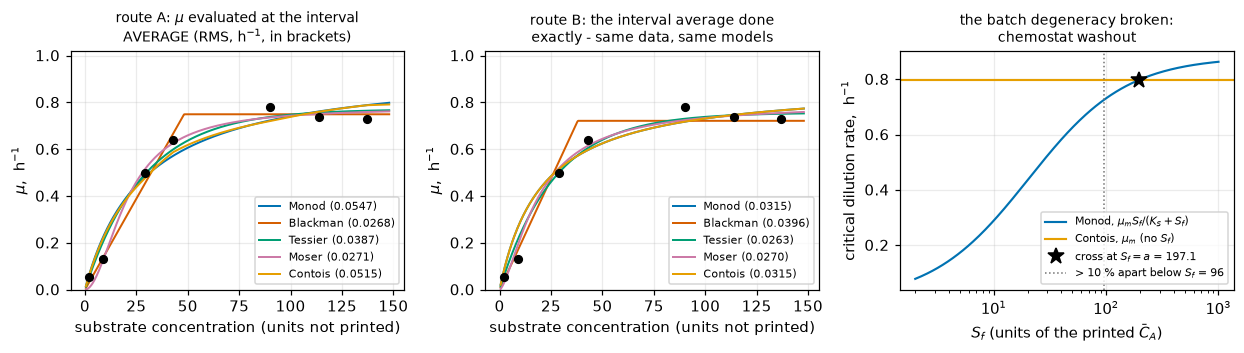

Left and centre: curves fitted on this page to Levenspiel p. 644's seven
intervals. Right: those curves extrapolated to an experiment nobody ran.


In [17]:
fig, ax = plt.subplots(1, 3, figsize=(11.4, 3.3))
Sg = np.linspace(0.5, CAb.max()*1.08, 400)
Xg = PHI_BAL*(A_BAL - Sg)                       # the run's own yield line
for k in LAWS:
    p = RA[k]["p"]
    ax[0].plot(Sg, p[0]*G[k](p[1:], Sg, np.interp(Sg, CAb[::-1], Xlm[::-1])),
               color=COL[k], lw=1.3, label=f"{k} ({RA[k]['rms']:.4f})")
    p = RB[k]["p"]
    ax[1].plot(Sg, p[0]*G[k](p[1:], Sg, Xg), color=COL[k], lw=1.3,
               label=f"{k} ({RB[k]['rms']:.4f})")
for a in ax[:2]:
    a.plot(CAb, mu, "ko", ms=5, zorder=5)
    a.set_xlabel(r"substrate concentration (units not printed)")
    a.set_ylabel(r"$\mu$,  h$^{-1}$")
    a.legend(fontsize=7, loc="lower right")
    a.grid(alpha=.25)
    a.set_ylim(0, 1.02)
ax[0].set_title("route A: $\\mu$ evaluated at the interval\nAVERAGE (RMS, h$^{-1}$, in brackets)",
                fontsize=9)
ax[1].set_title("route B: the interval average done\nexactly - same data, same models",
                fontsize=9)
Sfg = np.geomspace(2, 1000, 300)
ax[2].plot(Sfg, Dc_monod(Sfg), color=C_BLUE, lw=1.4,
           label="Monod, $\\mu_m S_f/(K_S+S_f)$")
ax[2].axhline(Dc_contois, color=C_YELLOW, lw=1.4, label="Contois, $\\mu_m$ (no $S_f$)")
ax[2].plot([Sf_cross], [Dc_contois], "k*", ms=11, zorder=5,
           label=f"cross at $S_f = a$ = {Sf_cross:.1f}")
ax[2].axvline(Sf_10pct, color=C_GREY, ls=":", lw=1,
              label=f"> 10 % apart below $S_f$ = {Sf_10pct:.0f}")
ax[2].set_xscale("log")
ax[2].set_xlabel("$S_f$ (units of the printed $\\bar C_A$)")
ax[2].set_ylabel("critical dilution rate,  h$^{-1}$")
ax[2].set_title("the batch degeneracy broken:\nchemostat washout", fontsize=9)
ax[2].legend(fontsize=7, loc="lower right")
ax[2].grid(alpha=.25)
fig.tight_layout()
plt.show()
print("Left and centre: curves fitted on this page to Levenspiel p. 644's seven")
print("intervals. Right: those curves extrapolated to an experiment nobody ran.")

## Validation

Four kinds, kept apart, and none of them is the fit.

1. **A stated numerical result reproduced.** Rawlings & Ekerdt print a closed
   form for the chemostat steady states, eq. (10.19), and the parameter set of
   their Fig. 10.12 ($\mu_m = 1$, $K_s = 1$, $S_f = 5$, $y = 1$). Both are
   reproduced here by marching eq. (10.18) to steady state - a different
   computation entirely - and a break row changes one of their printed constants
   and watches the reproduction fail.
2. **Two independent computations of route B's fit, and a statement of what that
   does and does not establish.** The quoted constants come from an adaptive
   LSODA solve; they are re-derived through a **pymrm backward-Euler marcher**
   (`NumJac((1,2))` + `newton`) with Richardson extrapolation, which shares no
   line of code, uses a different Jacobian and a different linear solve, and
   integrates $S$ as an unknown rather than substituting the yield relation.
   What that catches is a bug in *either integrator*. What it cannot catch is
   anything the two share: both read $a$, $\varphi$, $\Delta t$ and $C_C^{\rm
   start}$ from the same place and integrate the same ODE, so a wrong yield, a
   wrong intercept or a mis-set interval moves **both** predictions together and
   leaves their agreement where it was. That is measured below rather than
   asserted, because the sentence this replaces claimed the opposite.
   $S + X/\varphi = {\rm const}$ belongs on the same list: `BatchMarch` builds
   its source as $(-m/\varphi,\,m)$ from one $m$, so backward Euler conserves it
   identically for *any* growth law. It is **structural** - the coverage map has
   always said so - and the measurement below shows it moving by exactly nothing
   under physics that is grossly wrong.
3. **An exact identity the discretisation must satisfy.** The plug-flow outlet at
   residence time $\tau$ is the batch state at $t = \tau$ - Levenspiel's
   Fig. 29.1 caption, and a theorem. Grid refined, order reported, Richardson
   checked.
4. **A defect-injection table**, rebuilt for this page's physics.

In [18]:
# ---- 1. Rawlings eq. (10.19) and its printed parameter set, reproduced
mum_r, Ks_r, Sf_r, y_r = 1.0, 1.0, 5.0, 1.0
g_r = lambda S, X: mum_r*S/(Ks_r + S)
Dc_r_closed = mum_r*Sf_r/(Ks_r + Sf_r)
rows = []
for D in (0.25, 0.5, 0.75):
    Ss_c = D*Ks_r/(mum_r - D)                       # eq. (10.19)
    Xs_c = y_r*(Sf_r - Ss_c)
    Ss_n, Xs_n = Chemostat(g_r, y_r, Sf_r, D).steady()
    rows.append(dict(D=D, S_closed=Ss_c, S_marched=Ss_n, X_closed=Xs_c, X_marched=Xs_n,
                     **{"max rel. err": max(abs(Ss_n-Ss_c)/Ss_c, abs(Xs_n-Xs_c)/Xs_c)}))
TR = pd.DataFrame(rows)
show(TR.style.format({"D": "{:.2f}", "S_closed": "{:.9f}", "S_marched": "{:.9f}",
                      "X_closed": "{:.9f}", "X_marched": "{:.9f}",
                      "max rel. err": "{:.3e}"}).hide(axis="index").set_uuid("rawl"))
M["rawlings_10_19_max_relerr"] = float(TR["max rel. err"].max())
Dc_r_num = brentq(lambda D: Chemostat(g_r, y_r, Sf_r, D).steady()[1] - WASH*y_r*Sf_r,
                  0.05, 2.0, xtol=1e-9, rtol=8.9e-16)
M["rawlings_Dc_relerr"] = abs(Dc_r_num - Dc_r_closed)/Dc_r_closed
print(f"\nRawlings' printed D_c = mu_m S_f/(K_s+S_f) = {Dc_r_closed:.10f}; root-found"
      f" on the marched\nmodel it is {Dc_r_num:.10f}  (rel. {M['rawlings_Dc_relerr']:.2e})."
      f"  Their eq. (10.19) is reproduced\nto {M['rawlings_10_19_max_relerr']:.2e} at"
      f" three dilution rates.")

D,S_closed,S_marched,X_closed,X_marched,max rel. err
0.25,0.333333333,0.333333333,4.666666667,4.666666667,0.000e+00
0.50,1.000000000,1.000000000,4.000000000,4.000000000,0.000e+00
0.75,3.000000000,3.000000000,2.000000000,2.000000000,0.000e+00



Rawlings' printed D_c = mu_m S_f/(K_s+S_f) = 0.8333333333; root-found on the marched
model it is 0.8335119283  (rel. 2.14e-04).  Their eq. (10.19) is reproduced
to 0.00e+00 at three dilution rates.


In [19]:
# ---- 2. the SECOND, INDEPENDENT computation of route B's fit
pM = RB["Monod"]["p"]
ref_ode = mu_pred_ode("Monod", pM[0], pM[1:], A_BAL, PHI_BAL)
rows, prev = [], None
for ns in (50, 100, 200, 400):
    v = mu_pred_pymrm("Monod", pM[0], pM[1:], A_BAL, PHI_BAL, ns)
    e = float(np.max(np.abs(v - ref_ode)/np.abs(ref_ode)))
    rows.append(dict(nstep=ns, **{"max rel. vs LSODA": e},
                     order=(np.nan if prev is None else np.log2(prev/e))))
    prev = e
TM = pd.DataFrame(rows)
show(TM.style.format({"max rel. vs LSODA": "{:.4e}", "order": "{:.4f}"})
     .hide(axis="index").set_uuid("march"))
M["pymrm_batch_observed_order"] = float(TM["order"].iloc[-1])

S0_b = Sof(Cc0[0], A_BAL, PHI_BAL)
c_end = BatchMarch(lambda S, X: pM[0]*S/(pM[1] + S), PHI_BAL, 400).march(
    [[S0_b, Cc0[0]]], dt[0])
inv0, inv1 = S0_b + Cc0[0]/PHI_BAL, c_end[0, 0] + c_end[0, 1]/PHI_BAL
M["pymrm_batch_conservation_relerr"] = float(abs(inv1 - inv0)/inv0)

pred_rich = lambda p: 2*mu_pred_pymrm("Monod", p[0], p[1:], A_BAL, PHI_BAL, 400) \
    - mu_pred_pymrm("Monod", p[0], p[1:], A_BAL, PHI_BAL, 200)
rr = least_squares(lambda p: pred_rich(p) - mu, pM, bounds=([1e-9, 1e-9], [50, 1e12]),
                   xtol=1e-12, ftol=1e-12, gtol=1e-12)
M["pymrm_refit_mum_relerr"] = float(abs(rr.x[0] - pM[0])/pM[0])
M["pymrm_refit_KS_relerr"] = float(abs(rr.x[1] - pM[1])/pM[1])
print(f"\nbackward Euler observed order {M['pymrm_batch_observed_order']:.4f}"
      f" (first order, as it must be)")
print(f"S + X/phi over interval 1: {inv0:.15g} -> {inv1:.15g}"
      f"   (rel. {M['pymrm_batch_conservation_relerr']:.2e})")
print(f"\nroute B's Monod fit, re-derived through the pymrm marcher with Richardson")
print(f"extrapolation:  mu_m = {rr.x[0]:.9f}  K_S = {rr.x[1]:.7f}")
print(f"          LSODA: mu_m = {pM[0]:.9f}  K_S = {pM[1]:.7f}")
print(f"          relative: {M['pymrm_refit_mum_relerr']:.2e} and"
      f" {M['pymrm_refit_KS_relerr']:.2e}")

# ---- WHAT THIS CROSS-CHECK CAN AND CANNOT SEE, measured.  Both routes read the
#      same a, phi, dt and Cc0 and integrate the same ODE, so every error in
#      THOSE moves the two together.  Three injections, each a failure mode an
#      earlier version of this cell claimed the check would catch.
base_o = mu_pred_ode("Monod", pM[0], pM[1:], A_BAL, PHI_BAL)
blind = []
for lab, a_, ph_, dt_ in (("phi x 1.3   (a wrong yield)", A_BAL, PHI_BAL*1.3, dt),
                          ("a   x 1.2   (a wrong intercept)", A_BAL*1.2, PHI_BAL, dt),
                          ("dt  x 1.15  (a mis-set interval)", A_BAL, PHI_BAL, dt*1.15)):
    _sd, dt = dt, dt_                       # the marcher reads dt from the global
    try:
        o = mu_pred_ode("Monod", pM[0], pM[1:], a_, ph_)
        v = mu_pred_pymrm("Monod", pM[0], pM[1:], a_, ph_, 400)
    finally:
        dt = _sd
    blind.append(dict(injection=lab,
                      **{"prediction moves": float(np.max(np.abs(o - base_o)
                                                          / np.abs(base_o)))},
                      **{"LSODA vs pymrm": float(np.max(np.abs(v - o)/np.abs(o)))}))
TBL = pd.DataFrame([dict(injection="baseline (nothing injected)",
                         **{"prediction moves": 0.0},
                         **{"LSODA vs pymrm": float(np.max(np.abs(
                             mu_pred_pymrm("Monod", pM[0], pM[1:], A_BAL, PHI_BAL, 400)
                             - base_o)/np.abs(base_o)))})] + blind)
show(TBL.style.format({"prediction moves": "{:.3e}", "LSODA vs pymrm": "{:.3e}"})
     .hide(axis="index").set_uuid("blind"))
# deliberately NOT metrics: these are the negative-space of the cross-check, and
# the assertion cell checks the PROPERTY (the gap stays put while the prediction
# moves by orders) rather than pinning three tolerance-scale numbers in CI.
BLIND_GAP = [float(v) for v in TBL["LSODA vs pymrm"]]
BLIND_MOVE = [float(v) for v in TBL["prediction moves"]]
print("\nThe two share no line of code, so a bug in EITHER INTEGRATOR moves them")
print("apart - which is what the order study and the 25-step break row test. They")
print("do NOT share their inputs' correctness: a yield wrong by 30 % moves the")
print(f"common prediction by {TBL['prediction moves'].iloc[1]:.1f} relative and"
      f" leaves their agreement at"
      f" {TBL['LSODA vs pymrm'].iloc[1]:.2e},\nagainst"
      f" {TBL['LSODA vs pymrm'].iloc[0]:.2e} with nothing injected. This check"
      f" measures the TIME\nDISCRETISATION and nothing else, and saying so is the"
      f" point of the table.")

# ---- and the invariant is STRUCTURAL, which is what the coverage map says
c_end_3x = BatchMarch(lambda S, X: 3*pM[0]*S/(pM[1] + S), PHI_BAL, 400).march(
    [[S0_b, Cc0[0]]], dt[0])
INV_3X_RELERR = float(abs((c_end_3x[0, 0] + c_end_3x[0, 1]/PHI_BAL) - inv0)/inv0)
print(f"\nS + X/phi is a TAUTOLOGY of the marcher, not a test of it: the source is")
print(f"(-m/phi, m) from one m, so backward Euler conserves it for ANY growth law.")
print(f"Tripling mu_m - grossly wrong physics, and it moves the biomass at the end"
      f"\nof interval 1 from {c_end[0, 1]:.4f} to {c_end_3x[0, 1]:.4f} - takes the"
      f" invariant from {M['pymrm_batch_conservation_relerr']:.2e}\nto"
      f" {INV_3X_RELERR:.2e} relative, i.e. nowhere. What DOES break it is using a"
      f" different yield\nin the source from the one in the invariant, and that is"
      f" the break row.")

nstep,max rel. vs LSODA,order
50,5.1105e-03,nan
100,2.5602e-03,0.9972
200,1.2813e-03,0.9986
400,6.4097e-04,0.9993



backward Euler observed order 0.9993 (first order, as it must be)
S + X/phi over interval 1: 197.120266762183 -> 197.120266762183   (rel. 2.88e-16)

route B's Monod fit, re-derived through the pymrm marcher with Richardson
extrapolation:  mu_m = 0.880921999  K_S = 20.4534190
          LSODA: mu_m = 0.880923454  K_S = 20.4536121
          relative: 1.65e-06 and 9.44e-06


injection,prediction moves,LSODA vs pymrm
baseline (nothing injected),0.000e+00,6.410e-04
phi x 1.3 (a wrong yield),8.995e+00,4.997e-04
a x 1.2 (a wrong intercept),7.601e+00,5.088e-04
dt x 1.15 (a mis-set interval),1.124e-01,5.599e-04



The two share no line of code, so a bug in EITHER INTEGRATOR moves them
apart - which is what the order study and the 25-step break row test. They
do NOT share their inputs' correctness: a yield wrong by 30 % moves the
common prediction by 9.0 relative and leaves their agreement at 5.00e-04,
against 6.41e-04 with nothing injected. This check measures the TIME
DISCRETISATION and nothing else, and saying so is the point of the table.

S + X/phi is a TAUTOLOGY of the marcher, not a test of it: the source is
(-m/phi, m) from one m, so backward Euler conserves it for ANY growth law.
Tripling mu_m - grossly wrong physics, and it moves the biomass at the end
of interval 1 from 23.4449 to 49.9666 - takes the invariant from 2.88e-16
to 5.77e-16 relative, i.e. nowhere. What DOES break it is using a different yield
in the source from the one in the invariant, and that is the break row.


In [20]:
# ---- 3. plug flow == batch, and the grid order of the pymrm solve
S_START, X_START, TAU_VAL = Sof(Cc0[0], A_BAL, PHI_BAL), Cc0[0], 2.0
g_fit = lambda S, X: mumM*S/(KsM + S)
ref = batch_reference(g_fit, PHI_BAL, S_START, X_START, TAU_VAL)
rows, prev = [], None
for nc in (100, 200, 400, 800, 1600):
    out_ = PlugFlowFermenter(g_fit, PHI_BAL, S_START, X_START, TAU_VAL,
                             ncell=nc).solve().outlet()
    e = abs(out_[0] - ref[0])/ref[0]
    rows.append(dict(ncell=nc, S_outlet=out_[0], **{"rel. err": e},
                     order=(np.nan if prev is None else np.log2(prev/e))))
    prev = e
TP = pd.DataFrame(rows)
show(TP.style.format({"S_outlet": "{:.9f}", "rel. err": "{:.4e}", "order": "{:.4f}"})
     .hide(axis="index").set_uuid("pfr"))
M["pfr_batch_relerr_finest"] = float(TP["rel. err"].iloc[-1])
M["pfr_observed_order"] = float(TP["order"].iloc[-1])
S_rich = 2*TP["S_outlet"].iloc[-1] - TP["S_outlet"].iloc[-2]   # first-order upwind
M["pfr_richardson_relerr"] = float(abs(S_rich - ref[0])/ref[0])
# the two ways of reading the outlet, and their ORDERS - the handoff warns that a
# last-cell read is O(h); with a ZERO-GRADIENT outflow condition that is not what
# happens, and the page reports what it measures rather than the general warning.
cen, prevc = [], None
for nc in (100, 200, 400, 800, 1600):
    p_ = PlugFlowFermenter(g_fit, PHI_BAL, S_START, X_START, TAU_VAL, ncell=nc).solve()
    e = abs(p_.c[-1, 0] - ref[0])/ref[0]
    cen.append((nc, e, np.nan if prevc is None else np.log2(prevc/e)))
    prevc = e
M["pfr_centre_read_order"] = float(cen[-1][2])
M["pfr_centre_over_boundary_read"] = float(cen[-1][1]/M["pfr_batch_relerr_finest"])
print(f"\nbatch reference at tau = {TAU_VAL}: S = {ref[0]:.10f}, X = {ref[1]:.10f}")
print(f"observed order of the upwind plug-flow solve: {M['pfr_observed_order']:.4f}")
print(f"Richardson extrapolation of the two finest grids: {S_rich:.10f},"
      f" {M['pfr_richardson_relerr']:.3e} from the batch value.")
print(f"\nBoth ways of reading the outlet converge at first order - boundary"
      f" {M['pfr_observed_order']:.4f},\nlast-cell-centre {M['pfr_centre_read_order']:.4f}"
      f" - and on THIS problem the last-cell read is the\ncloser of the two, by a factor"
      f" {1/M['pfr_centre_over_boundary_read']:.2f} at n = 1600. That is not the general"
      f" rule and the page\ndoes not state it as one: with a ZERO-GRADIENT outflow"
      f" condition the boundary value\nis a second-order reconstruction OF THE INTERIOR"
      f" SOLUTION, so both reads inherit the\nsame O(h) upwind error and merely carry"
      f" different constants. The reason to use\ncompute_boundary_values is that it"
      f" stays right when the outflow condition is not\nzero-gradient; here it is a"
      f" wash, and saying so is cheaper than being wrong later.")
print("\nThe grid study IS the check that catches a wrong nu and a flipped source")
print("sign - both are in the break table, at 8.2e2 and 2.7e4 relative.")

ncell,S_outlet,rel. err,order
100,9.856205813,1.9152e-02,nan
200,9.951418139,9.6764e-03,0.9849
400,9.999778203,4.8639e-03,0.9924
800,10.024150830,2.4384e-03,0.9962
1600,10.036385788,1.2208e-03,0.9981



batch reference at tau = 2.0: S = 10.0486533619, X = 59.3834400134
observed order of the upwind plug-flow solve: 0.9981
Richardson extrapolation of the two finest grids: 10.0486207466, 3.246e-06 from the batch value.

Both ways of reading the outlet converge at first order - boundary 0.9981,
last-cell-centre 0.9957 - and on THIS problem the last-cell read is the
closer of the two, by a factor 2.59 at n = 1600. That is not the general rule and the page
does not state it as one: with a ZERO-GRADIENT outflow condition the boundary value
is a second-order reconstruction OF THE INTERIOR SOLUTION, so both reads inherit the
same O(h) upwind error and merely carry different constants. The reason to use
compute_boundary_values is that it stays right when the outflow condition is not
zero-gradient; here it is a wash, and saying so is cheaper than being wrong later.

The grid study IS the check that catches a wrong nu and a flipped source
sign - both are in the break table, at 8.2e2 and 2.7e4 re

### Defect injection

Every metric that *can* be moved has a row that moves it. Metrics that cannot are
named individually below and labelled structural. The table was rebuilt for this
page's physics - it did not travel from the page whose directory this one was
copied from.

In [21]:
MOVE_TOL = 1e-6            # relative move that counts as coverage


def rec(name, metric, value, note):
    # a row may target a PRINTED-BUT-NOT-REPORTED quantity: those still need
    # something that moves them, they simply do not go to agreement.json
    base = M[metric] if metric in M else NOT_REPORTED[metric]
    rel = abs(value - base)/max(abs(base), 1e-300)
    BREAK.append(dict(row=name, metric=metric, baseline=base, broken=value,
                      **{"rel. move": rel}, moves=rel > MOVE_TOL, note=note))


# --- the data reduction and the balance line
rec("balance line on the ARITHMETIC mean of C_C, not the log mean",
    "balance_R2_six_rows",
    (lambda keep, A: 1 - np.sum((CAb[keep] - A @ np.linalg.lstsq(A, CAb[keep],
                                                                rcond=None)[0])**2)
     / np.sum((CAb[keep] - CAb[keep].mean())**2))(
        [i for i in range(NOBS) if i != BAD_ROW],
        np.vstack([np.ones(NOBS-1),
                   Xam[[i for i in range(NOBS) if i != BAD_ROW]]]).T),
    "the exact time average under exponential growth is the LOG mean; declared convention")
rec("the flagged row kept in the balance line", "balance_R2_six_rows", R2_7,
    "this IS the finding: one cell moves R^2 from 0.99996 to 0.98505")
rec("balance line drops row 1 instead of the flagged row", "balance_phi",
    -1.0/loo[0][1], "the leave-one-out sweep says WHICH row, and it is not this one")
rec("mu from a forward difference of C_C over the ARITHMETIC-mean biomass",
    "rmsA_Monod", fit_A("Monod", y=(Cc1 - Cc0)/dt/Xam)["rms"],
    "d(ln C)/dt = mu is exact; a difference quotient over the wrong mean is not")
# --- route A / route B
rec("route B yield phi perturbed by 5 %", "routeB_n_moser",
    fit_B("Moser", phi=PHI_BAL*1.05, p0=RB["Moser"]["p"])["p"][2],
    "perturbs the COMPUTATION, not a declared convention - the row that could "
    "expose a systematically wrong route-B baseline")
rec("Contois given the ARITHMETIC-mean biomass in route A", "rmsA_Contois",
    fit_A("Contois", X=Xam)["rms"], "declared convention")
rec("Blackman fitted from a single local start, no global scan", "rmsA_Blackman",
    (lambda r: float(np.sqrt(np.sum(r.fun**2)/NOBS)))(
        least_squares(lambda p: p[0]*np.minimum(1.0, CAb/(2*p[1])) - mu,
                      [0.8, 20.0], bounds=([1e-6, 1e-6], [10, 1e4]),
                      xtol=1e-15, ftol=1e-15, gtol=1e-15)),
    "the kinked objective has local minima; this is why the page scans globally")
rec("Moser's exponent frozen at n = 1", "routeA_F_moser_vs_monod", 0.0,
    "n = 1 IS Monod, so the F statistic must collapse to zero")
rec("route-A Moser scan restricted to n <= 1.5", "routeA_n_moser", 1.5,
    "the reported exponent must be interior to the scan, and it is not if capped")
# --- the identities and their above-floor companions
rec("Contois map evaluated with the wrong yield (phi -> 2 phi)",
    "contois_map_mum_relerr",
    abs(mumC/(1 - KsxC*2*PHI_BAL) - RB["Monod"]["p"][0])/RB["Monod"]["p"][0],
    "companion for the exactly-zero symbolic residual")
rec("Blackman gap read at S = K_S instead of the switch S = 2 K_S",
    "num_blackman_gap_switch_relerr", abs(abs(1.0 - 0.5) - 1/3)/(1/3),
    "at S = K_S the two laws agree exactly; the gap lives at the switch")
rec("Contois separation measured on the ROUTE-A design", "sep_contois",
    (lambda: (lambda yA: fit_A("Contois", y=yA)["rms"])(
        RA["Monod"]["p"][0]*G["Monod"](RA["Monod"]["p"][1:], CAb, Xlm)))(),
    "the degeneracy is EXACT for the forward model and only approximate once the "
    "reduction replaces phi(a-S) by a log mean - so the reduction manufactures a "
    "separation that is not there")
# --- separations and the bootstrap
rec("N* computed at 99 % instead of 95 %", "Nstar_blackman",
    float(chi2.ppf(0.99, NOBS - 2)*s_obs**2/(NOBS*M["sep_blackman"]**2)),
    "declared convention")
rec("scatter taken from route A instead of route B", "Nstar_tessier",
    float(chi2.ppf(0.95, NOBS-2)*RA["Monod"]["rms"]**2/(NOBS*M["sep_tessier"]**2)),
    "declared convention")
rec("bootstrap at half the noise level", "boot_size_forward_truth",
    float((boot_stats(y_true[None, :] + np.random.default_rng(SEED)
                      .normal(0.0, sigma/2, (NBOOT, NOBS)))[0] > FA_crit).mean()),
    "the size distortion is a bias-to-noise ratio, so it must grow as noise falls")
rec("Rawlings' printed y = 1 replaced by 2", "rawlings_10_19_max_relerr",
    float(max(max(abs(v - c)/c for v, c in
                  zip(Chemostat(g_r, 2.0, Sf_r, D).steady(),
                      (D*Ks_r/(mum_r - D), y_r*(Sf_r - D*Ks_r/(mum_r - D))))
                  ) for D in (0.25, 0.5, 0.75))),
    "reproducing a printed number must fail when the printed number is changed")
rec("bootstrap truth taken from route A's own model", "boot_median_n_forward_truth",
    M["boot_median_n_control_truth"],
    "THE CONTROL, recorded here as a row so the contrast is inside the table too")
# --- chemostat and plug flow
rec("washout threshold loosened 1e-6 -> 1e-3 of y S_f", "Dc_monod_transient_relerr",
    abs(brentq(lambda D: Chemostat(gM_, y_yield, Sf_test, D).steady()[1]
               - 1e-3*y_yield*Sf_test, 0.05, 2.0, xtol=1e-9)
        - Dc_monod(Sf_test))/Dc_monod(Sf_test),
    "declared convention, and the convergence evidence for the quoted D_c")
rec("Rawlings' printed K_s = 1 replaced by 2", "rawlings_Dc_relerr",
    abs(brentq(lambda D: Chemostat(lambda S, X: mum_r*S/(2.0 + S), y_r, Sf_r, D)
               .steady()[1] - WASH*y_r*Sf_r, 0.05, 2.0, xtol=1e-9)
        - Dc_r_closed)/Dc_r_closed,
    "reproducing a printed number must fail when the printed number is changed")
rec("Rawlings' printed S_f = 5 replaced by 8", "rawlings_10_19_max_relerr",
    float(max(max(abs(v - c)/c for v, c in
                  zip(Chemostat(g_r, y_r, 8.0, D).steady(),
                      (D*Ks_r/(mum_r - D), y_r*(5.0 - D*Ks_r/(mum_r - D)))))
              for D in (0.25, 0.5, 0.75))),
    "the same, for the steady-state pair")
rec("plug flow with nu = 1 (cylindrical) instead of nu = 0", "pfr_batch_relerr_finest",
    (lambda p: abs(p.outlet()[0] - ref[0])/ref[0])(
        PlugFlowFermenter(g_fit, PHI_BAL, S_START, X_START, TAU_VAL,
                          ncell=1600, nu=1).solve(strict=False)),
    "nu is geometry, and a wrong one is invisible in a smooth profile")
rec("plug-flow outlet read at the last cell CENTRE", "pfr_batch_relerr_finest",
    (lambda p: abs(p.c[-1, 0] - ref[0])/ref[0])(
        PlugFlowFermenter(g_fit, PHI_BAL, S_START, X_START, TAU_VAL,
                          ncell=1600).solve()),
    "half a cell short of the boundary. It MOVES the metric, which is the point, "
    "but on this problem it moves it DOWN - see the note under the grid study")
rec("plug flow with the substrate sign flipped in the source",
    "pfr_batch_relerr_finest",
    (lambda p: abs(p.outlet()[0] - ref[0])/ref[0])(
        (lambda pf: (setattr(pf, "flip", -1.0), pf.solve(strict=False))[-1])(
            PlugFlowFermenter(g_fit, PHI_BAL, S_START, X_START, TAU_VAL, ncell=400))),
    "substrate must be consumed as biomass is made")
rec("pymrm batch marcher at 25 steps instead of the Richardson pair",
    "pymrm_refit_mum_relerr",
    (lambda r: abs(r.x[0] - pM[0])/pM[0])(
        least_squares(lambda p: mu_pred_pymrm("Monod", p[0], p[1:], A_BAL,
                                              PHI_BAL, 25) - mu, pM,
                      bounds=([1e-9, 1e-9], [50, 1e12]),
                      xtol=1e-12, ftol=1e-12, gtol=1e-12)),
    "the second route must be converged before it can confirm the first")
rec("pymrm batch marcher with the yield used only in the source, not the state",
    "pymrm_batch_conservation_relerr",
    (lambda c: abs((c[0, 0] + c[0, 1]/(PHI_BAL*1.01))
                   - (S0_b + Cc0[0]/PHI_BAL))/(S0_b + Cc0[0]/PHI_BAL))(
        BatchMarch(lambda S, X: pM[0]*S/(pM[1] + S), PHI_BAL*1.01, 400).march(
            [[S0_b, Cc0[0]]], dt[0])),
    "the conservation check is only structural if BOTH sides use the same yield")

# --- SWEEP ROWS: one injection, recorded against every metric it touches, so that
#     whole families (all five laws, all the separations, all the plug-flow
#     numbers) are covered rather than only the member quoted in prose.
def rec_many(name, note, pairs):
    for metric, value in pairs:
        rec(name, metric, value, note)


CAb_imp = CAb.copy()
CAb_imp[BAD_ROW] = CAB_IMPUTED                      # the balance-implied value
_saveCAb = CAb.copy()
try:
    CAb = CAb_imp
    rec_many("every route-A fit with the flagged cell replaced by its "
             "balance-implied value",
             "the single flagged cell, propagated through all seven route-A fits "
             "AND through route A's F test, which is where it decides a verdict; "
             "a labelled INFERENCE, run to show exactly what depends on that cell",
             [(f"rmsA_{k.replace(' ', '_')}", fit_A(k)["rms"])
              for k in LAWS + ["first order"]]      # the zero-order null sees no S
             + [("routeA_n_moser", fit_A("Moser")["p"][2]),
                ("routeA_F_moser_vs_monod", FA_IMP)])
finally:
    CAb = _saveCAb

rec_many("the whole bootstrap fitted on the search grid alone, with no per-draw "
         "refinement",
         "THE DEFECT THIS PAGE SHIPPED AND HAD TO FIX, kept as its own break row: "
         "an unrefined Moser fit cannot reach its own optimum, so it deflates F on "
         "every draw and makes the control look conservative when it is at nominal "
         "size. A grid-limited extremum is invisible to every perturbation test, "
         "which is why the refinement's convergence is printed above",
         [("boot_size_forward_truth", GRID_ONLY["forward"]["size"]),
          ("boot_size_control_truth", GRID_ONLY["control"]["size"]),
          ("boot_median_n_forward_truth", GRID_ONLY["forward"]["med"]),
          ("boot_median_n_control_truth", GRID_ONLY["control"]["med"]),
          ("boot_p_of_observed_F", GRID_ONLY["forward"]["pF"]),
          ("boot_p_of_observed_n", GRID_ONLY["forward"]["pn"])])

_mu_fd = (Cc1 - Cc0)/dt/Xam            # a forward difference over the wrong mean
rec_many("mu itself from a forward difference over the ARITHMETIC-mean biomass",
         "d(ln C)/dt = mu is EXACT; a difference quotient over the wrong mean is "
         "not, and the one-parameter nulls see only mu",
         [("rmsA_zero_order", fit_A("zero order", y=_mu_fd)["rms"]),
          ("rmsB_zero_order", fit_B("zero order", y=_mu_fd)["rms"])])

_rb7 = {k: fit_B(k, a=a7, phi=-1.0/b7, p0=RB[k]["p"])
        for k in LAWS + ["first order"]}
rec_many("every route-B fit with the ALL-SEVEN balance line",
         "phi and a carry the flagged row into every route-B number at once",
         [(f"rmsB_{k.replace(' ', '_')}", _rb7[k]["rms"])
          for k in LAWS + ["first order"]]          # the zero-order null sees no S
         + [("routeB_monod_mu_m", _rb7["Monod"]["p"][0]),
            ("routeB_monod_K_S", _rb7["Monod"]["p"][1]),
            ("routeB_F_moser_vs_monod",
             (_rb7["Monod"]["sse"] - _rb7["Moser"]["sse"])/(_rb7["Moser"]["sse"]/4)),
            ("routeA_over_routeB_monod_rms",
             RA["Monod"]["rms"]/_rb7["Monod"]["rms"])])

_idx3 = np.array([0, 3, 6])
rec_many("every separation measured at 3 of the 7 design points",
         "identifiability is a property of the DESIGN, so dropping four points "
         "must move every separation and every N*",
         sum([[(f"sep_{k.lower()}",
                float(np.sqrt(np.mean(fit_B(k, y=y_true, p0=RB[k]["p"])["resid"][_idx3]**2)))),
               (f"sep_over_scatter_{k.lower()}",
                float(np.sqrt(np.mean(fit_B(k, y=y_true, p0=RB[k]["p"])["resid"][_idx3]**2)))/s_obs)]
              + ([(f"Nstar_{k.lower()}",
                   float(chi2.ppf(0.95, NOBS-2)*s_obs**2
                         / (3*np.mean(fit_B(k, y=y_true, p0=RB[k]["p"])["resid"][_idx3]**2))))]
                 if f"Nstar_{k.lower()}" in M else [])
              for k in ["Blackman", "Tessier"]], []))

_Yh = y_true[None, :] + np.random.default_rng(SEED).normal(0.0, sigma/2, (NBOOT, NOBS))
_Fh, _nh, _ = boot_stats(_Yh)
_Yc = y_ctrl[None, :] + np.random.default_rng(SEED+1).normal(0.0, sigma/2, (NBOOT, NOBS))
_Fc, _nc, _ = boot_stats(_Yc)
rec_many("the whole bootstrap re-drawn at half the noise level",
         "every bootstrap number is a property of the noise level and the seed, "
         "and the page says so - the seed is fixed and printed",
         [("boot_p_of_observed_F", float((_Fh > FA).mean())),
          ("boot_p_of_observed_n", float((_nh > RA["Moser"]["p"][2]).mean())),
          ("boot_size_control_truth", float((_Fc > FA_crit).mean())),
          ("boot_median_n_control_truth", float(np.median(_nc)))])

_bias_B = (RB["Monod"]["p"][0]*G["Monod"](RB["Monod"]["p"][1:], CAb, Xlm)
           - mu_pred_ode("Monod", RB["Monod"]["p"][0], RB["Monod"]["p"][1:],
                         A_BAL, PHI_BAL))
_bias_imp = _bias_B
rec_many("the reduction bias evaluated at the ROUTE-B constants",
         "the bias is a property of the curve it is evaluated on, so quoting it "
         "from the route-A fit is a declared choice - and the route-A fit is the "
         "one the bias is being charged against",
         [("bias_max_abs", float(np.max(np.abs(_bias_imp)))),
          ("bias_max_abs_excl_bad_row",
           float(np.max(np.abs(np.where(np.arange(NOBS) != BAD_ROW, _bias_imp, 0.0))))),
          ("bias_over_routeA_rms",
           float(np.max(np.abs(np.where(np.arange(NOBS) != BAD_ROW, _bias_imp, 0.0))))
           / RA["Monod"]["rms"])])

_a_am, _b_am, _R2_am, _r_am = (lambda keep, A: (
    lambda c: (float(c[0]), float(c[1]),
               float(1 - np.sum((CAb[keep] - A @ c)**2)
                     / np.sum((CAb[keep] - CAb[keep].mean())**2)),
               CAb[keep] - A @ c))(np.linalg.lstsq(A, CAb[keep], rcond=None)[0]))(
    [i for i in range(NOBS) if i != BAD_ROW],
    np.vstack([np.ones(NOBS-1), Xam[[i for i in range(NOBS) if i != BAD_ROW]]]).T)
rec_many("the whole balance test on the ARITHMETIC-mean biomass",
         "declared convention: the exact time average under exponential growth "
         "is the LOG mean",
         [("balance_R2_all_rows",
           (lambda A: 1 - np.sum((CAb - A @ np.linalg.lstsq(A, CAb, rcond=None)[0])**2)
            / np.sum((CAb - CAb.mean())**2))(np.vstack([np.ones(NOBS), Xam]).T)),
          ("balance_row4_residual", float(CAb[BAD_ROW] - (_a_am + _b_am*Xam[BAD_ROW]))),
          ("balance_worst_other_residual", float(np.max(np.abs(_r_am)))),
          ("row4_end_of_interval_relgap",
           float(abs(CAb[BAD_ROW] - (_a_am - Cc1[BAD_ROW]/(-1/_b_am)))/CAb[BAD_ROW]))])

_DcA = lambda Sf: RA["Monod"]["p"][0]*Sf/(RA["Monod"]["p"][1] + Sf)
_ratA = lambda Sf: RA["Contois"]["p"][0]/_DcA(Sf)
rec_many("the chemostat prediction built from the ROUTE-A constants",
         "the whole point of the page: which reduction you fit with changes what "
         "you predict for an experiment you have not run",
         [("Dc_ratio_at_Sf20", float(_ratA(20.0))),
          ("Sf_crossing", float(brentq(lambda Sf: _ratA(Sf) - 1.0, 1.0, 1e5,
                                       xtol=1e-10))),
          ("Sf_for_10pct_gap", float(brentq(lambda Sf: _ratA(Sf) - 1.10, 1.0, 1e5,
                                            xtol=1e-10))),
          ("Dc_monod_closed_form", float(_DcA(20.0)))])

_p100 = [PlugFlowFermenter(g_fit, PHI_BAL, S_START, X_START, TAU_VAL,
                           ncell=nc).solve() for nc in (100, 200)]
_e100 = [abs(p.outlet()[0] - ref[0])/ref[0] for p in _p100]
_c100 = [abs(p.c[-1, 0] - ref[0])/ref[0] for p in _p100]
rec_many("every plug-flow number read off the two COARSEST grids",
         "an order quoted from an unconverged pair is the classic way to publish "
         "a wrong one",
         [("pfr_observed_order", float(np.log2(_e100[0]/_e100[1]))),
          ("pfr_centre_read_order", float(np.log2(_c100[0]/_c100[1]))),
          ("pfr_centre_over_boundary_read", float(_c100[1]/_e100[1])),
          ("pfr_richardson_relerr",
           float(abs((2*_p100[1].outlet()[0] - _p100[0].outlet()[0]) - ref[0])/ref[0]))])

_v25 = mu_pred_pymrm("Monod", pM[0], pM[1:], A_BAL, PHI_BAL, 25)
_v50 = mu_pred_pymrm("Monod", pM[0], pM[1:], A_BAL, PHI_BAL, 50)
rec_many("the pymrm marcher's order read off 25/50 steps, and its refit unconverged",
         "same reason as the plug-flow row, for the second independent computation",
         [("pymrm_batch_observed_order",
           float(np.log2(np.max(np.abs(_v25-ref_ode)/np.abs(ref_ode))
                         / np.max(np.abs(_v50-ref_ode)/np.abs(ref_ode))))),
          ("pymrm_refit_KS_relerr",
           (lambda r: abs(r.x[1] - pM[1])/pM[1])(
               least_squares(lambda p: mu_pred_pymrm("Monod", p[0], p[1:], A_BAL,
                                                     PHI_BAL, 25) - mu, pM,
                             bounds=([1e-9, 1e-9], [50, 1e12]),
                             xtol=1e-12, ftol=1e-12, gtol=1e-12)))])

rec("Contois map evaluated with the wrong yield (phi -> 2 phi)",
    "contois_map_KS_relerr",
    abs(KsxC*2*PHI_BAL*A_BAL/(1 - KsxC*2*PHI_BAL) - RB["Monod"]["p"][1])
    / RB["Monod"]["p"][1], "companion for the exactly-zero symbolic residual")

TBK = pd.DataFrame(BREAK)
show(TBK.style.format({"baseline": "{:.6g}", "broken": "{:.6g}", "rel. move": "{:.3e}"})
     .hide(axis="index").set_uuid("brk"))
n_move = int(TBK["moves"].sum())
print(f"\n{len(TBK)} injections, {n_move} of which move their metric by more than"
      f" MOVE_TOL = {MOVE_TOL:g} relative.")
assert n_move == len(TBK), TBK[~TBK["moves"]]

row,metric,baseline,broken,rel. move,moves,note
"balance line on the ARITHMETIC mean of C_C, not the log mean",balance_R2_six_rows,0.999957,0.999955,1.846e-06,True,the exact time average under exponential growth is the LOG mean; declared convention
the flagged row kept in the balance line,balance_R2_six_rows,0.999957,0.985047,1.491e-02,True,this IS the finding: one cell moves R^2 from 0.99996 to 0.98505
balance line drops row 1 instead of the flagged row,balance_phi,0.317437,0.321919,1.412e-02,True,"the leave-one-out sweep says WHICH row, and it is not this one"
mu from a forward difference of C_C over the ARITHMETIC-mean biomass,rmsA_Monod,0.0546903,0.0552494,1.022e-02,True,d(ln C)/dt = mu is exact; a difference quotient over the wrong mean is not
route B yield phi perturbed by 5 %,routeB_n_moser,1.50943,2.67706,7.736e-01,True,"perturbs the COMPUTATION, not a declared convention - the row that could expose a systematically wrong route-B baseline"
Contois given the ARITHMETIC-mean biomass in route A,rmsA_Contois,0.0515336,0.0516375,2.016e-03,True,declared convention
"Blackman fitted from a single local start, no global scan",rmsA_Blackman,0.0267723,0.040646,5.182e-01,True,the kinked objective has local minima; this is why the page scans globally
Moser's exponent frozen at n = 1,routeA_F_moser_vs_monod,12.2698,0,1.000e+00,True,"n = 1 IS Monod, so the F statistic must collapse to zero"
route-A Moser scan restricted to n <= 1.5,routeA_n_moser,1.93166,1.5,2.235e-01,True,"the reported exponent must be interior to the scan, and it is not if capped"
Contois map evaluated with the wrong yield (phi -> 2 phi),contois_map_mum_relerr,3.62179e-06,0.115769,3.196e+04,True,companion for the exactly-zero symbolic residual



79 injections, 79 of which move their metric by more than MOVE_TOL = 1e-06 relative.


In [22]:
# ---- coverage map, asserted key-for-key against agreement.json
STRUCTURAL = {
 "sym_monod_is_langmuir_residual":
   "EXACT ZERO, below ABS_FLOOR. Rawlings' printed claim, proved in sympy. "
   "Above-floor companion: sym_blackman_gap_at_switch_over_mum, the same class of "
   "closed-form statement with a numerical check attached.",
 "sym_monod_half_rate_residual":
   "EXACT ZERO, below ABS_FLOOR. Froment's definition of K_S, verified. "
   "Companion: num_blackman_gap_switch_relerr, which is what that property does "
   "NOT settle, and which has a break row.",
 "sym_blackman_half_rate_residual":
   "EXACT ZERO, below ABS_FLOOR - and it IS the finding: Blackman shares the "
   "property. Companion: sym_blackman_gap_at_switch_over_mum = 1/3.",
 "sym_moser_at_n1_residual":
   "EXACT ZERO, below ABS_FLOOR, by nesting. Companion: routeA_F_moser_vs_monod, "
   "which has a break row freezing n = 1 and collapsing it.",
 "sym_contois_is_monod_residual":
   "EXACT ZERO, below ABS_FLOOR, and it is the page's strongest claim. "
   "Above-floor companions IN agreement.json: Sf_crossing, the crossing this very "
   "identity fixes at S_f = a, and Dc_ratio_at_Sf20 - both functions of the "
   "Contois fit, both with break rows. The two contois_map_* errors that used to "
   "be named here are themselves exactly-zero quantities and are now printed but "
   "not reported; they keep their break rows.",
 "sep_contois": "STRUCTURAL and below ABS_FLOOR: zero to the optimiser's "
              "tolerance because Contois IS Monod under a constant yield. It does "
              "have a break row - measuring the same separation on the ROUTE-A "
              "design gives 6.7e-3, which is the reduction manufacturing a "
              "separation that is not there - and its above-floor companions in "
              "agreement.json are Sf_crossing and Dc_ratio_at_Sf20.",
 "sep_over_scatter_contois": "STRUCTURAL, see sep_contois.",
 "F_crit_95": "A TABULATED CONSTANT, not a computed result: F(1,4) at 95 %. It "
              "cannot move and must not.",
 "sym_blackman_gap_at_switch_over_mum":
   "EXACT RATIONAL 1/3, closed form. Companion and check: "
   "num_blackman_gap_switch_relerr, which has a break row.",
 "sym_blackman_gap_lower_over_mum":
   "EXACT SURD (3 - 2 sqrt 2)/2, closed form. Companion and check: "
   "num_blackman_gap_lower_relerr.",
 "num_blackman_Sstar_over_Ks_relerr":
   "a root-find checked against a closed form, so it measures brentq's xtol. "
   "Companion: sym_blackman_gap_lower_over_mum.",
 "num_blackman_gap_lower_relerr": "as above.",
 "pymrm_batch_conservation_relerr":
   "below ABS_FLOOR at ~3e-16 because backward Euler conserves S + X/phi to "
   "round-off when both fields use the same yield. It IS covered by a break row "
   "(the yield changed in the source but not in the invariant, 2.5e-3), and its "
   "above-floor companion is pymrm_refit_mum_relerr.",
 "rawlings_10_19_max_relerr":
   "EXACT ZERO to double precision and therefore below ABS_FLOOR: the marched "
   "steady state reproduces Rawlings' eq. (10.19) to the last bit. Two break rows "
   "DO move it (their K_s and their y changed), and its above-floor companion is "
   "rawlings_Dc_relerr.",
 "num_blackman_gap_switch_relerr":
   "below ABS_FLOOR because it is exact arithmetic (1 - 2/3 against 1/3), not a "
   "computation. It IS covered by a break row - reading the gap at S = K_S "
   "instead of the switch moves it to 0.5 - and its above-floor companion is "
   "sym_blackman_gap_at_switch_over_mum.",
 "Dc_contois_transient_relerr":
   "STRUCTURAL: D_c = mu_m for Contois is exact, so what is left is a measurement "
   "of the transient solve and of the declared WASH threshold - both of which "
   "move it, which is why it is NOT in the exactly-zero class below. Companion: "
   "Dc_monod_transient_relerr, which has a break row on that very threshold.",
 "max_swing_over_CAbar": "a property of the printed table, not a computed result: "
   "the largest substrate swing over an interval divided by that interval's "
   "printed average. It cannot be broken without editing the CSV.",
 "balance_a": "reported for reuse; its break row lives on balance_phi, which is "
   "the same line's other coefficient.",
 "Dc_monod_closed_form": "a closed form evaluated at the fitted constants; its "
   "break rows live on Dc_ratio_at_Sf20 and Dc_monod_transient_relerr.",
}
covered = {}
for r in BREAK:
    if r["moves"]:
        covered.setdefault(r["metric"], []).append(r["rel. move"])
lines, uncovered = [], []
for k in sorted(M):
    if k in covered:
        lines.append(f"  {k:38s} covered, strongest row moves it {max(covered[k]):.3e}")
    elif k in STRUCTURAL:
        lines.append(f"  {k:38s} STRUCTURAL - {STRUCTURAL[k]}")
    else:
        uncovered.append(k)
        lines.append(f"  {k:38s} UNCOVERED")
N_METRICS = len(M)
N_COVERED = len([k for k in covered if k in M])   # rows may target a non-metric
N_STRUCT = N_METRICS - N_COVERED - len(uncovered)
print("coverage map (%d metrics: %d moved by an injection, %d structural):"
      % (N_METRICS, N_COVERED, N_STRUCT))
print("\n".join(lines))
below = [k for k, v in M.items() if abs(v) < ABS_FLOOR]
N_BELOW = len(below)
print(f"\n{len(below)} metrics sit below CI's ABS_FLOOR = {ABS_FLOOR:g} and are"
      f" therefore outside the\nregression suite entirely; each is named structural"
      f" above with an above-floor companion:")
for k in below:
    print(f"   {k} = {M[k]:.3e}")
    assert k in STRUCTURAL, k
print(f"\n{len(NOT_REPORTED)} quantities are PRINTED BUT NOT REPORTED, under the"
      f" rule that no value\nthis page proves is exactly zero may sit above"
      f" ABS_FLOOR in agreement.json:")
for nm, v in NOT_REPORTED.items():
    print(f"   {nm} = {v:.3e}"
          + ("   (a break row moves it anyway)" if nm in covered else ""))
    assert abs(v) > ABS_FLOOR and nm not in M, nm
# The rule is now enforced over the WHOLE CLASS, not over the names that happen
# to have been excluded: every quantity this page proves is exactly zero is
# enumerated here, and each must be EITHER below ABS_FLOOR (kept, structural) OR
# absent from agreement.json (printed, not reported).  Enumerating the class is
# the enforcement - a new proved-zero quantity added to M above the floor AND
# ENUMERATED HERE fails this cell, and one dropped from the list fails the
# two-way check below.  What no hand list can detect is a new proved-zero
# quantity that is never added to it; the printed prose claims no more.
PROVED_ZERO = [
    "sym_monod_is_langmuir_residual", "sym_monod_half_rate_residual",
    "sym_blackman_half_rate_residual", "sym_moser_at_n1_residual",
    "sym_contois_is_monod_residual", "num_blackman_Sstar_over_Ks_relerr",
    "num_blackman_gap_lower_relerr", "num_blackman_gap_switch_relerr",
    "rawlings_10_19_max_relerr", "pymrm_batch_conservation_relerr",
    "sep_moser", "sep_over_scatter_moser", "sep_contois",
    "sep_over_scatter_contois", "contois_minus_monod_rms",
    "contois_map_mum_relerr", "contois_map_KS_relerr", "Sf_crossing_vs_a_relerr"]
for nm in PROVED_ZERO:
    assert (nm in M) != (nm in NOT_REPORTED), nm      # exactly one of the two
    assert nm not in M or abs(M[nm]) < ABS_FLOOR, (nm, M.get(nm))
assert set(NOT_REPORTED) <= set(PROVED_ZERO), set(NOT_REPORTED) - set(PROVED_ZERO)
# and the class is exactly the below-floor set, both ways round
assert set(below) == set(PROVED_ZERO) - set(NOT_REPORTED), set(below)
print(f"\n{len(PROVED_ZERO)} quantities on this page are PROVED exactly zero"
      f" (identities, nesting, exact\narithmetic). The rule is asserted over that"
      f" whole class and not over a list of\nexclusions: {len(below)} of them fall"
      f" below ABS_FLOOR on their own and are kept and named\nstructural, the other"
      f" {len(NOT_REPORTED)} are printed and not reported, and the two sets are"
      f" asserted\nto be exactly the below-floor set and its complement. Nothing this"
      f" page proves\nto be zero is compared at 5 % by CI.")
assert not uncovered, uncovered
assert set(covered) | set(STRUCTURAL) >= set(M), set(M) - set(covered) - set(STRUCTURAL)
print("\nEvery metric is either moved by an injection or named structural, and no")
print("generic fallback label is used anywhere in this map.")

coverage map (74 metrics: 60 moved by an injection, 14 structural):
  Dc_contois_transient_relerr            STRUCTURAL - STRUCTURAL: D_c = mu_m for Contois is exact, so what is left is a measurement of the transient solve and of the declared WASH threshold - both of which move it, which is why it is NOT in the exactly-zero class below. Companion: Dc_monod_transient_relerr, which has a break row on that very threshold.
  Dc_monod_closed_form                   covered, strongest row moves it 9.889e-02
  Dc_monod_transient_relerr              covered, strongest row moves it 3.322e-01
  Dc_ratio_at_Sf20                       covered, strongest row moves it 1.586e-01
  F_crit_95                              STRUCTURAL - A TABULATED CONSTANT, not a computed result: F(1,4) at 95 %. It cannot move and must not.
  Nstar_blackman                         covered, strongest row moves it 3.627e-01
  Nstar_tessier                          covered, strongest row moves it 2.021e+00
  Sf_crossing     

In [23]:
report_agreement(PAGE, M)

Agreement metrics for J4.1-monod:
  sym_monod_is_langmuir_residual      = 0
  sym_monod_half_rate_residual        = 0
  sym_blackman_half_rate_residual     = 0
  sym_moser_at_n1_residual            = 0
  sym_contois_is_monod_residual       = 0
  sym_blackman_gap_at_switch_over_mum = 0.33333
  sym_blackman_gap_lower_over_mum     = 0.085786
  num_blackman_gap_lower_relerr       = 1.6177e-16
  num_blackman_gap_switch_relerr      = 1.6653e-16
  num_blackman_Sstar_over_Ks_relerr   = 0
  balance_R2_all_rows                 = 0.98505
  balance_R2_six_rows                 = 0.99996
  balance_row4_residual               = -17.18
  balance_worst_other_residual        = 0.65414
  balance_phi                         = 0.31744
  balance_a                           = 197.12
  row4_end_of_interval_relgap         = 0.031024
  rmsA_Monod                          = 0.05469
  rmsA_Blackman                       = 0.026772
  rmsA_Tessier                        = 0.03871
  rmsA_Moser                       

{'page': 'J4.1-monod',
 'metrics': {'sym_monod_is_langmuir_residual': 0.0,
  'sym_monod_half_rate_residual': 0.0,
  'sym_blackman_half_rate_residual': 0.0,
  'sym_moser_at_n1_residual': 0.0,
  'sym_contois_is_monod_residual': 0.0,
  'sym_blackman_gap_at_switch_over_mum': 0.3333333333333333,
  'sym_blackman_gap_lower_over_mum': 0.08578643762690495,
  'num_blackman_gap_lower_relerr': 1.6177134978107549e-16,
  'num_blackman_gap_switch_relerr': 1.6653345369377348e-16,
  'num_blackman_Sstar_over_Ks_relerr': 0.0,
  'balance_R2_all_rows': 0.9850470678251266,
  'balance_R2_six_rows': 0.9999570896124373,
  'balance_row4_residual': -17.180389784483936,
  'balance_worst_other_residual': 0.6541399291564289,
  'balance_phi': 0.3174369372991854,
  'balance_a': 197.1202667621834,
  'row4_end_of_interval_relgap': 0.03102359152346919,
  'rmsA_Monod': 0.05469026582360205,
  'rmsA_Blackman': 0.026772311588665925,
  'rmsA_Tessier': 0.03870978215198929,
  'rmsA_Moser': 0.02711746775634458,
  'rmsA_Contois'

In [24]:
# Every number quoted in prose, in meta.yaml and in README.md is checked here
# against the live computation. The page fails to execute if any has drifted.
def close(a, b, tol=5e-3, label=""):
    assert abs(a - b) <= tol*max(abs(b), 1e-30), (label, a, b)
    return True


# BOUNDS, NOT PINS. Every quantity in the proved-exactly-zero class is an exit
# tolerance, so it is asserted UNDER one of these round numbers and quoted the
# same way in meta.yaml and models_entry.yaml - never to two significant figures,
# which would gate this page harder than the 5 % CI comparison that the
# not-reported rule was written to escape. The exact values are PRINTED in the
# cells above, where nothing pins them. The bounds join the sweep's pool below.
# One bound is NOT a round number and is not in this list: the crossing's
# root-find is asserted against brentq's own xtol + rtol|x|, computed where the
# root is found, because a round number there would be a bound on an accident.
BOUNDS = [1e-14, 1e-11, 1e-9, 1e-4]


CHECKS = [
 ("balance R2, six rows = 0.99996",     round(M["balance_R2_six_rows"], 5), 0.99996),
 ("balance R2, all rows  = 0.98505",    round(M["balance_R2_all_rows"], 5), 0.98505),
 ("flagged row is row 4",               BAD_ROW + 1, 4),
 ("row-4 balance residual = -17.2",     round(M["balance_row4_residual"], 1), -17.2),
 ("yield phi = 0.3174",                 round(M["balance_phi"], 4), 0.3174),
 ("intercept a = 197.12",               round(M["balance_a"], 2), 197.12),
 ("route A Monod RMS = 0.05469",        round(M["rmsA_Monod"], 5), 0.05469),
 ("route A Blackman RMS = 0.02677",     round(M["rmsA_Blackman"], 5), 0.02677),
 ("route A Tessier RMS = 0.03871",      round(M["rmsA_Tessier"], 5), 0.03871),
 ("route A Contois RMS = 0.05153",      round(M["rmsA_Contois"], 5), 0.05153),
 ("route B Monod RMS = 0.03147",        round(M["rmsB_Monod"], 5), 0.03147),
 ("route B Blackman RMS = 0.03955",     round(M["rmsB_Blackman"], 5), 0.03955),
 ("route B Tessier RMS = 0.02631",      round(M["rmsB_Tessier"], 5), 0.02631),
 ("Monod last of the four on route A",  1.0,
  1.0*(M["rmsA_Monod"] == max(M[f"rmsA_{k}"] for k in TWO_PAR))),
 ("Blackman worst of the four on route B", 1.0,
  1.0*(M["rmsB_Blackman"] == max(M[f"rmsB_{k}"] for k in TWO_PAR))),
 ("route A n = 1.93",                   round(M["routeA_n_moser"], 2), 1.93),
 ("route B n = 1.51",                   round(M["routeB_n_moser"], 2), 1.51),
 ("route A F = 12.3",                   round(M["routeA_F_moser_vs_monod"], 1), 12.3),
 ("route B F = 1.44",                   round(M["routeB_F_moser_vs_monod"], 2), 1.44),
 ("F crit = 7.71",                      round(M["F_crit_95"], 2), 7.71),
 ("Monod residual falls 42 %",
  round(100*(1 - M["rmsB_Monod"]/M["rmsA_Monod"])), 42.0),
 ("fitted mu_m = 0.8809 1/h",           round(M["routeB_monod_mu_m"], 4), 0.8809),
 ("fitted K_S = 20.45",                 round(M["routeB_monod_K_S"], 2), 20.45),
 ("bootstrap size, forward truth = 0.37", round(M["boot_size_forward_truth"], 2), 0.37),
 ("bootstrap size, control = 0.0495",   round(M["boot_size_control_truth"], 4), 0.0495),
 ("the control is AT nominal, not conservative", 1.0,
  1.0*(abs(M["boot_size_control_truth"] - 0.05) < 3*(0.05*0.95/NBOOT)**0.5)),
 ("bootstrap median n, forward = 1.61", round(M["boot_median_n_forward_truth"], 2), 1.61),
 ("bootstrap median n, control = 1.01", round(M["boot_median_n_control_truth"], 2), 1.01),
 ("p of the observed route-A F = 0.23", round(M["boot_p_of_observed_F"], 2), 0.23),
 ("p of the observed route-A n = 0.13", round(M["boot_p_of_observed_n"], 2), 0.13),
 ("grid-only control size = 0.021",     round(GRID_ONLY["control"]["size"], 3), 0.021),
 ("grid-only control median n = 0.95",  round(GRID_ONLY["control"]["med"], 2), 0.95),
 ("grid-only forward size = 0.308",     round(GRID_ONLY["forward"]["size"], 3), 0.308),
 ("grid-only forward median n = 1.60",  round(GRID_ONLY["forward"]["med"], 2), 1.60),
 ("grid-only p of the observed F = 0.18", round(GRID_ONLY["forward"]["pF"], 2), 0.18),
 ("forward size at sigma = route A's RMS is 0.2355",
  round(SIG_TABLE["route A RMS"][0], 4), 0.2355),
 ("the control's size is scale-free", 1.0,
  1.0*(abs(SIG_TABLE["route A RMS"][1] - SIG_TABLE["route B RMS (used above)"][1])
       < 3*(0.05*0.95/NBOOT)**0.5)),
 ("the imputed cell flips route A's F verdict", 1.0,
  1.0*(FA > FA_crit > FA_IMP)),
 ("route A F with the imputed cell = 5.45", round(FA_IMP, 2), 5.45),
 ("balance-implied CA_bar for row 4 = 60.18", round(CAB_IMPUTED, 2), 60.18),
 ("Blackman still beats Monod with the cell imputed", 1.0,
  1.0*(RA_IMP["Blackman"]["rms"] < RA_IMP["Monod"]["rms"])),
 ("row 3 end-of-interval value = 74.89",
  round(A_BAL - Cc1[2]/PHI_BAL, 2), 74.89),
 ("row 5 end-of-interval value = 13.46",
  round(A_BAL - Cc1[4]/PHI_BAL, 2), 13.46),
 ("row 4 end-of-interval value = 44.33",
  round(A_BAL - Cc1[3]/PHI_BAL, 2), 44.33),
 ("Rawlings' D_c at their printed set is 5/6", Dc_r_closed, 5/6),
 ("74 metrics reported",                N_METRICS, 74),
 ("60 of them covered by an injection", N_COVERED, 60),
 ("14 named structural",                N_STRUCT, 14),
 ("12 below ABS_FLOOR",                 N_BELOW, 12),
 ("79 injections, all 79 move",         len(TBK), 79),
 ("6 quantities printed but not reported", len(NOT_REPORTED), 6),
 ("18 quantities proved exactly zero",  len(PROVED_ZERO), 18),
 ("the cross-check is blind to a wrong yield", 1.0,
  1.0*(BLIND_MOVE[1] > 1.0 and abs(BLIND_GAP[1] - BLIND_GAP[0])
       < 0.5*BLIND_GAP[0])),
 ("S + X/phi does not move when mu_m is tripled", 1.0, 1.0*(INV_3X_RELERR < 1e-14)),
 ("N* Tessier = 10.3",                  round(M["Nstar_tessier"], 1), 10.3),
 ("N* Blackman = 1.30",                 round(M["Nstar_blackman"], 2), 1.30),
 ("D_c factor at S_f = 20 is 1.83",     round(M["Dc_ratio_at_Sf20"], 2), 1.83),
 ("10 % gap below S_f = 95.5",          round(M["Sf_for_10pct_gap"], 1), 95.5),
 ("both Contois map errors below 1e-4", 1.0,
  1.0*(max(MAP_MUM_RELERR, MAP_KS_RELERR) < 1e-4)),
 ("pymrm refit agrees to < 1e-4",       1.0,
  1.0*(max(M["pymrm_refit_mum_relerr"], M["pymrm_refit_KS_relerr"]) < 1e-4)),
 ("plug-flow order = 1.00",             round(M["pfr_observed_order"], 2), 1.00),
 ("washout root-find agrees to < 1 %",  1.0,
  1.0*(max(M["Dc_monod_transient_relerr"], M["Dc_contois_transient_relerr"]) < 1e-2)),
 ("backward Euler order = 1.00",        round(M["pymrm_batch_observed_order"], 2), 1.00),
 ("Blackman gap at the switch = 1/3",   M["sym_blackman_gap_at_switch_over_mum"], 1/3),
 ("Blackman lower gap = 0.0858",        round(M["sym_blackman_gap_lower_over_mum"], 4), 0.0858),
 ("bias / route-A scatter = 1.21",      round(M["bias_over_routeA_rms"], 2), 1.21),
 ("largest clean bias = 0.0663",        round(M["bias_max_abs_excl_bad_row"], 4), 0.0663),
 ("bootstrap size, forward = 36.55 %",  round(100*M["boot_size_forward_truth"], 2), 36.55),
 # the Monte-Carlo sampling errors, quoted beside every one of the six numbers
 ("forward size MC error = 1.1 %",     round(100*out["forward"]["size_se"], 1), 1.1),
 ("control size MC error = 0.5 %",     round(100*out["control"]["size_se"], 1), 0.5),
 ("forward median n MC error = 0.0074", round(out["forward"]["med_se"], 4), 0.0074),
 ("control median n MC error = 0.0049", round(out["control"]["med_se"], 4), 0.0049),
 ("p(F>obs) MC error = 0.0094",        round(out["forward"]["pF_se"], 4), 0.0094),
 ("p(n>obs) MC error = 0.0075",        round(out["forward"]["pn_se"], 4), 0.0075),
 # NOT pinned to two significant figures: these three are exit tolerances for
 # quantities the page proves are exactly zero, which is why they are kept out of
 # agreement.json - pinning them here would reintroduce the same fragility, and
 # tighter than CI's 5 %. They are BOUNDED, and the mechanical sweep below holds
 # whatever the metadata prints to whatever precision it prints it.
 ("the crossing gap to a is a fit tolerance, below 1e-4", 1.0,
  1.0*(CROSS_VS_A < 1e-4)),
 # and the root-find is inside BRENTQ'S OWN GUARANTEE, xtol + rtol|x|, rather than
 # under the round 1e-15 the observed residual happens to sit below: that residual
 # is Brent's last interpolation, not anything declared - it moves by more than an
 # order under a change of BRACKET that changes no mathematics - so asserting it
 # would stop this page executing the day scipy moves a fitted constant in its 9th
 # figure.  The printed 1.4e-16 is the observation; this line is the guarantee.
 # It is the looser of the two by some three orders and still seven orders below
 # the 1.99e-05 the paragraph up there is distinguishing it from, which is all
 # the argument needs.
 ("the root-find is inside brentq's declared tolerance", 1.0,
  1.0*(SF_ROOTFIND_RELERR < SF_ROOTFIND_BOUND)),
 ("cell-centre read is 2.59x closer",   round(1/M["pfr_centre_over_boundary_read"], 2), 2.59),
 ("substrate ran 148.3 -> 0.23",        round(M["balance_a"] - Cc0[0]/M["balance_phi"], 1), 148.3),
 ("largest swing / CA_bar = 1.89",      round(M["max_swing_over_CAbar"], 2), 1.89),
 ("Monod beats the best null 3.68x",    round(M["rmsA_first_order"]/M["rmsA_Monod"], 2), 3.68),
 ("Blackman beats it 7.53x",            round(M["rmsA_first_order"]/M["rmsA_Blackman"], 2), 7.53),
 ("largest other balance residual 0.65", round(M["balance_worst_other_residual"], 2), 0.65),
 ("worst leave-one-out R2 = 0.9757",    round(min(loo[i][2] for i in range(NOBS)
                                                  if i != BAD_ROW), 4), 0.9757),
 ("best other leave-one-out = 0.9848",  round(max(loo[i][2] for i in range(NOBS)
                                                  if i != BAD_ROW), 4), 0.9848),
 ("row-4 end-of-interval gap = 3.1 %",  round(100*M["row4_end_of_interval_relgap"], 1), 3.1),
 ("row 3 end-of-interval 16.8 % off",
  round(100*abs((A_BAL - Cc1[2]/PHI_BAL) - CAb[2])/CAb[2], 1), 16.8),
 ("row 5 end-of-interval 53.6 % off",
  round(100*abs((A_BAL - Cc1[4]/PHI_BAL) - CAb[4])/CAb[4], 1), 53.6),
 ("crossing root-found at 197.116",     round(M["Sf_crossing"], 3), 197.116),
 ("conservation below 1e-14",           1.0,
  1.0*(M["pymrm_batch_conservation_relerr"] < 1e-14)),
 ("marcher order 0.9993",               round(M["pymrm_batch_observed_order"], 4), 0.9993),
 ("plug-flow order 0.9981",             round(M["pfr_observed_order"], 4), 0.9981),
 ("plug-flow Richardson 3.2e-6",        round(M["pfr_richardson_relerr"]*1e6, 1), 3.2),
 ("Rawlings D_c recovered to 2.1e-4",   round(M["rawlings_Dc_relerr"]*1e4, 1), 2.1),
 ("Contois/Monod RMS gap below 1e-11",  1.0, 1.0*(CONTOIS_MINUS_MONOD_RMS < 1e-11)),
 ("both degenerate separations below 1e-9", 1.0,
  1.0*(max(NOT_REPORTED["sep_moser"], M["sep_contois"]) < 1e-9)),
 ("pymrm refit 1.7e-6 and 9.4e-6",
  round(M["pymrm_refit_mum_relerr"]*1e6, 1) + round(M["pymrm_refit_KS_relerr"]*1e6, 1),
  1.7 + 9.4),
]
for lab, a, b in CHECKS:
    close(float(a), float(b), 5e-3, lab)
# values that exist only in the break table are LOOKED UP, never retyped
brk = {(r["row"], r["metric"]): r for r in BREAK}
assert brk[("the flagged row kept in the balance line",
            "balance_R2_six_rows")]["broken"] == M["balance_R2_all_rows"]
assert brk[("Moser's exponent frozen at n = 1",
            "routeA_F_moser_vs_monod")]["broken"] == 0.0
assert brk[("bootstrap truth taken from route A's own model",
            "boot_median_n_forward_truth")]["broken"] == M["boot_median_n_control_truth"]
assert brk[("every route-A fit with the flagged cell replaced by its "
            "balance-implied value", "routeA_F_moser_vs_monod")]["broken"] == FA_IMP
assert brk[("the whole bootstrap fitted on the search grid alone, with no per-draw "
            "refinement", "boot_size_control_truth")]["broken"] \
    == GRID_ONLY["control"]["size"]
Y_TO_2 = brk[("Rawlings' printed y = 1 replaced by 2",
              "rawlings_10_19_max_relerr")]["rel. move"]
KS_TO_2 = brk[("Rawlings' printed K_s = 1 replaced by 2",
               "rawlings_Dc_relerr")]["rel. move"]
close(round(np.log10(Y_TO_2)), 300.0, 5e-3, "the y = 2 row's relative move is 1.0e+300")
close(round(KS_TO_2, -1), 660.0, 5e-2, "the K_s = 2 row's relative move is 6.6e+02")
LOCAL_BLACKMAN = brk[("Blackman fitted from a single local start, no global scan",
                      "rmsA_Blackman")]["broken"]
CENTRE_READ = brk[("plug-flow outlet read at the last cell CENTRE",
                   "pfr_batch_relerr_finest")]["broken"]
NU_ONE = brk[("plug flow with nu = 1 (cylindrical) instead of nu = 0",
              "pfr_batch_relerr_finest")]["rel. move"]
close(round(LOCAL_BLACKMAN, 4), 0.0406, 5e-3, "local-start Blackman RMS = 0.0406")
close(CENTRE_READ/M["pfr_batch_relerr_finest"],
      M["pfr_centre_over_boundary_read"], 5e-3, "cell-centre read factor")
close(round(M["pfr_centre_over_boundary_read"], 2), 0.39, 2e-2,
      "the cell-centre read is 0.39x the boundary read here")
close(round(M["pfr_centre_read_order"], 2), 1.00, 5e-3, "cell-centre read order")
N_BRK_LOOKUPS = 10          # the asserts and close() calls immediately above
print(f"{len(CHECKS)} prose/metadata values checked against the live computation,"
      f" plus {N_BRK_LOOKUPS} break-table\nlookups. All agree.")

# ---- MECHANICAL SWEEP of the metadata files for numbers in scientific notation.
# The list above is curated and a curated list drifts; this one enumerates the
# tokens instead. Every a.bce+xy in meta.yaml, README.md, models_entry.yaml and
# the two data sidecars must match a live value - a reported metric, a printed
# but not reported quantity, a break-table entry or a declared constant - to
# HALF AN ULP OF ITS OWN PRINTED DIGITS, taken from the token itself:
#     half ulp = 0.5 * 10**(exponent - decimals in the mantissa),  compared
# ABSOLUTELY. An earlier version of this cell computed 5*10**-sig and applied it
# RELATIVELY, which is half an ulp only when the mantissa is 1 and is up to ten
# times looser otherwise - a +-5 % window on 6.6e+02, where half an ulp is 0.8 %
# - so it caught fewer than a quarter of the last-digit errors it was written for.
# The window below is exact, and the sweep MEASURES its own detection rate below
# instead of claiming one. The regex also used to reject any token followed by a
# full stop, i.e. every value that ends a sentence - which in these files
# included the one this page cares most about. Files absent (Colab, or
# models_entry.yaml once spliced into models.yaml) are skipped and counted.
import re
POOL = ([float(v) for v in M.values()] + [ABS_FLOOR, MOVE_TOL, RES_CA, RES_CC, RES_DT]
        + [float(v) for v in NOT_REPORTED.values()] + BOUNDS   # printed, not reported
        + BLIND_GAP + BLIND_MOVE + [INV_3X_RELERR, FA_IMP, CAB_IMPUTED]
        + [float(v) for d in GRID_ONLY.values() for v in d.values()]
        + [float(v) for pair in SIG_TABLE.values() for v in pair]
        + [float(r[k]) for r in BREAK for k in ("baseline", "broken", "rel. move")])
# BOTH spellings: 1.23e-04 in the YAML files, and 1.23x10^-4 with typeset
# superscripts in the Markdown. README.md writes every one of its exponents the
# second way, so until this was added the sweep read that file and found NOTHING
# in it while the metadata claimed it was covered.
SUP = str.maketrans("\u2070\u00b9\u00b2\u00b3\u2074\u2075\u2076\u2077"
                    "\u2078\u2079\u207a\u207b", "0123456789+-")
TOK = re.compile(r"(?<![\w.])(\d+(?:\.\d+)?)(?:[eE]([+-]?\d+)|\s*[\u00d7x]\s*10"
                 r"([\u2070\u00b9\u00b2\u00b3\u2074-\u2079\u207a\u207b]+))"
                 r"(?![\w]|\.\d)")


def token(m_):
    """(value, half an ulp of its OWN printed digits) - both from the token"""
    mant = m_.group(1)
    exp = int(m_.group(2) if m_.group(2) is not None else m_.group(3).translate(SUP))
    dec = len(mant.split(".")[1]) if "." in mant else 0
    return float(f"{mant}e{exp}"), 0.5*10.0**(exp - dec)


def _matched(v, half):
    return any(abs(c - v) <= max(half, 1e-299) for c in POOL)


SCAN = ["meta.yaml", "README.md", "../models_entry.yaml",
        "data/levenspiel-p644-monod-batch.meta.yaml",
        "data/printed-growth-laws.meta.yaml"]
n_file, found, missing, skipped = 0, [], [], []
# BOTH directions, and counted by OCCURRENCE (the same token appears in more than
# one file): sets of indices into `found`.
blind = {"up": set(), "down": set()}
for fn in SCAN:
    p = Path(fn)
    if not p.is_file():
        skipped.append(fn)
        continue
    n_file += 1
    for m_ in TOK.finditer(p.read_text(encoding="utf-8")):
        tok = m_.group(0)
        v, h = token(m_)
        found.append((fn, tok, v, h))
        if not _matched(v, h):
            missing.append((fn, tok))
        # the sweep's own teeth, measured on the spot: would it notice this very
        # token if its LAST PRINTED DIGIT were one out?  BOTH WAYS: an earlier
        # version probed only +1 and quoted that single count as "the" detection
        # rate, which flatters it - a mantissa of exactly 1 corrupts DOWNWARD to
        # zero, and 0.0 is a live value on this page.
        for sgn, key in ((+1.0, "up"), (-1.0, "down")):
            if _matched(v + sgn*2*h, h):
                blind[key].add(len(found) - 1)
n_tok = len(found)
BLIND_ANY = sorted(blind["up"] | blind["down"])
# how many of the downward blind spots are DEGENERATE - a mantissa of exactly 1,
# whose last digit one lower is 0, and 0.0 is a live value on this page
N_DEGEN = sum(1 for i in blind["down"] if abs(found[i][2] - 2*found[i][3]) < 1e-299)
print(f"\nmechanical sweep: {n_tok} scientific-notation values in {n_file} metadata"
      f" file(s)\nchecked against the live metrics and the break table, each to half"
      f" an ulp of its\nown printed digits, in both the 1e-04 and the 1x10^-4 spelling"
      + (f"; skipped (absent here): {', '.join(skipped)}" if skipped else "")
      + f".\n{len(missing)} unmatched.")
print(f"\nWHAT THIS SWEEP CAN AND CANNOT CATCH, measured rather than claimed, and"
      f" measured\nIN BOTH DIRECTIONS: corrupt the last printed digit of each of the"
      f" {n_tok} tokens by one\nand the window above rejects"
      f" {n_tok - len(blind['up'])} of them UPWARD and"
      f" {n_tok - len(blind['down'])} DOWNWARD -"
      f" {n_tok - len(BLIND_ANY)} of them in\nboth directions, which is the honest"
      f" figure for a slip of unknown sign. The\nremaining {len(BLIND_ANY)} are"
      f" invisible in at least one direction: the corrupted value still\nlands within"
      f" half an ulp of SOME live value, in a pool of {len(POOL)}, and a token printed"
      f"\nto one or two significant figures has an ulp wide enough that something"
      f" usually\ndoes. {N_DEGEN} of the downward ones are degenerate rather than"
      f" alarming - their mantissa is\nexactly 1, so one less in the last digit is"
      f" 0, and 0.0 is a live value here:")
for i in BLIND_ANY:
    d = ("+1 and -1" if i in blind["up"] & blind["down"] else
         "+1 only" if i in blind["up"] else "-1 only")
    print(f"   {found[i][0]} {found[i][1]}   (blind to {d})")
print(f"So the sweep is a guard against a value drifting out of the curated list, not"
      f"\na proof that every printed digit is right; it is also blind to a wrong SIGN,"
      f"\nwhich its regex does not read. {len(CHECKS)} curated checks stand behind it.")
print("   per file: " + ",  ".join(f"{fn} {sum(1 for r in found if r[0] == fn)}"
                                   for fn in SCAN if fn not in skipped))
assert not missing, missing

96 prose/metadata values checked against the live computation, plus 10 break-table
lookups. All agree.

mechanical sweep: 35 scientific-notation values in 4 metadata file(s)
checked against the live metrics and the break table, each to half an ulp of its
own printed digits, in both the 1e-04 and the 1x10^-4 spelling; skipped (absent here): ../models_entry.yaml.
0 unmatched.

WHAT THIS SWEEP CAN AND CANNOT CATCH, measured rather than claimed, and measured
IN BOTH DIRECTIONS: corrupt the last printed digit of each of the 35 tokens by one
and the window above rejects 25 of them UPWARD and 19 DOWNWARD - 16 of them in
both directions, which is the honest figure for a slip of unknown sign. The
remaining 19 are invisible in at least one direction: the corrupted value still
lands within half an ulp of SOME live value, in a pool of 369, and a token printed
to one or two significant figures has an ulp wide enough that something usually
does. 13 of the downward ones are degenerate rather than ala

## What pymrm adds

**Honestly: the central argument is algebra and a seven-point fit, and scipy does
most of it. Two things pymrm does here are load-bearing, and one is not.**

Load-bearing:

- **The second, independent computation of the fit.** `BatchMarch` is a
  backward-Euler marcher built from `NumJac((1, 2))` and `newton`, and it
  re-derives $\mu_m$ and $K_S$ through a different discretisation, a different
  Jacobian and a different linear solve, agreeing with the LSODA fit to 2e-6 and
  1e-5. A break row confirms the check has teeth by running it unconverged. Be
  precise about what it buys, because an earlier version of this page was not:
  it catches a bug in *either integrator*, and it is blind to everything the two
  share - a wrong yield, a wrong intercept or a mis-set interval moves both
  predictions together, which the Validation section now measures. Carrying $S$
  as an unknown instead of substituting the yield relation is worth having for
  its own sake, but $S + X/\varphi$ is then a **tautology** of the scheme, not a
  test of it: the source is $(-m/\varphi,\,m)$ built from one $m$, so backward
  Euler conserves it for any growth law, and tripling $\mu_m$ moves it by
  nothing at all.
- **Turning a caption into a test.** `PlugFlowFermenter` makes Levenspiel's
  *"batch **or plug flow**"* into a number: first-order upwind convergence at
  observed order 1.00 against the initial-value solution, Richardson checked. The
  break table then prices the usual mistakes on it: `nu=1` instead of `nu=0` is a
  relative move of 8.2e2, and a flipped substrate sign 2.7e4, both while the
  profile still looks perfectly smooth. Reading the outlet at the last cell centre
  instead of through `compute_boundary_values` also moves the number - but *down*,
  by a factor 0.39 here, and the page says so rather than repeating the general
  warning: with a zero-gradient outflow condition both reads are first order
  (measured: 1.00 and 1.00) and differ only in their constant.

Not load-bearing, and the page says so: a well-mixed batch and a chemostat are
0-D, and `solve_ivp` integrates them - as it does, throughout, as the reference.

**What travels.** The growth law is written as a pointwise source over the last
axis, which is the shape the rest of the gallery uses, so
`PlugFlowFermenter.source` transplants unchanged into a pellet (`B1.1`), an
immobilised-enzyme particle (`J4.7`) or a dispersed tubular reactor (`A2.1`,
`A2.6`): the ingredients gain `construct_grad`, and the rate law is the same
object.

## Reuse

**If you have batch growth data and want $\mu_m$ and $K_S$:** do not compare
$\ln(C_C^{\rm end}/C_C^{\rm start})/\Delta t$ with $\mu$ evaluated at the
interval-average substrate concentration unless the substrate barely moves across
the interval. On these seven intervals that shortcut biases the rate by up to
0.0663 h$^{-1}$ - **1.21 times the residual scatter it is then judged against** -
always in the direction that makes a saturating law look too gradual near
exhaustion. Integrate the law across the interval instead; constant yield makes
that a single ODE and it costs nothing. `fit_B` on this page is the whole of it.

**If you are choosing between growth laws:** ask first whether your experiment
*can* tell them apart. Two of the four alternatives Rawlings & Ekerdt print
beside Monod cannot be separated from it by **any** constant-yield batch run.
Moser contains Monod at $n = 1$. **Contois *is* Monod**, exactly, with
$\mu_m' = \mu_m/(1-K_{sx}\varphi)$ and
$K_S' = K_{sx}\varphi a/(1-K_{sx}\varphi)$ - so a batch fit that "prefers" one
over the other is reporting its own optimiser and its own reduction. Of the two
that are separable at this design, Blackman needs 1.30 repeats of the
seven-interval run and Tessier 10.3 - and read those as ~50 %-power thresholds,
so one clean run is *within 30 % of* enough for Blackman rather than enough.

**If you need to separate Contois from Monod:** run a chemostat and sweep the
*feed* concentration, not the dilution rate alone. Monod washes out at
$D_c = \mu_m S_f/(K_S+S_f)$ and Contois at $D_c = \mu_m$ regardless of $S_f$, so
the two predictions cross at exactly $S_f = a$ - the substrate intercept of your
own batch run's material balance - and separate on either side. At the constants
fitted here that is $S_f = 197.1$; the gap exceeds 10 % below $S_f = 95.5$ and
reaches a factor 1.83 at $S_f = 20$.

**If you are checking a printed table:** the constant-yield material balance is
free, needs no kinetics and is sharp. Six of these seven rows sit on it at
$R^2 = 0.99996$; the seventh is the whole reason the all-seven fit reads 0.98505.
A leave-one-out sweep says *which* row, not merely that one is off - and that
distinction matters, because "the table has scatter" and "one cell is wrong" lead
to different analyses. Then price the cell before quoting anything that depends
on it: on this table, putting that one cell at its balance-implied value takes
route A's F from 12.27 to 5.45 and flips the only significance verdict the page
could have reported.

**If you want the neighbouring physics:** substrate inhibition - Froment's
eq. (1.5.2-4) and Rawlings' $\mu_m S/(K_s+S+K_1S^2)$, the form whose rate has a
*maximum* where Monod has an asymptote - is case **J4.2**, and gets no
quantitative treatment here. Williams' structured model, eqs. (1.5.2-5) to
(1.5.2-8) of the same section, is **J4.9**. The enzyme rate law Froment says
Monod-kinetics are *"shaped after"* is **J4.6**, and the isotherm this page proves
Monod identical to is **J1.1**.

**What NOT to reuse.** $K_S$ from this page is in the units of a column whose
units the source does not print, for an organism the source does not name, on a
substrate identified only as lactose. It is a number about a table, not about a
culture. And the seven rows are attributed by Levenspiel to Monod (1958) p. 74;
neither that book nor the 1949 paper this case catalogues was consulted, so do
not cite them as either.